In [2]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')    

import numpy as np
import datetime
import networkx as nx
import pandas as pd

from utils_graphs import *
from utils_data_vis import *

In [3]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas identificadas en el artículo de Beiró and Gandica et al.
HORA_CRITICA_NAT = "429624"
HORA_CRITICA_9N = "437061"
HORA_CRITICA_9N = "437037"
HORA_CRITICA_CH = "394717"

hour_window_nat = 1
hour_window_9n = 2
hour_window_ch = 2

limites = True

# AUTOSIMILITUD EN LAS REDES

## Redes normales (hashtags como nodos) 

In [3]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200

dict_hora_nat_h = get_dict_hora_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_9n_h = get_dict_hora_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_ch_h = get_dict_hora_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

100%|██████████| 200/200 [00:00<00:00, 1625.48it/s]


In [4]:
limit_kt_nat_h = 35
limit_kt_9n_h = 60
limit_kt_ch_h = 25

critical_kt_nat_h = 30
critical_kt_9n_h = 40
critical_kt_ch_h = 15

arr_kt_plot_nat_h = [0,2,4,8,9,10]
arr_kt_plot_9n_h = [0,10,15,20,25,30,35,40]
arr_kt_plot_ch_h = [0,7,9,11,13,15]



In [5]:
plfit_nat_h, arr_pdf_points_nat_h, arr_ccdf_points_nat_h = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_nat_h, exp=False, norm=True, read=False)
plfit_9n_h, arr_pdf_points_9n_h, arr_ccdf_points_9n_h = calc_degree_distribution(HORA_CRITICA_9N,  "9n/" + str(hour_window_9n) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_9n_h, exp=False, norm=True, read=False)
plfit_ch_h, arr_pdf_points_ch_h, arr_ccdf_points_ch_h = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_h, exp=False, norm=True, read=False)

100%|██████████| 6/6 [00:00<00:00, 329.81it/s]


In [6]:
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/')
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/')
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/')

100%|██████████| 200/200 [00:00<00:00, 290.82it/s]


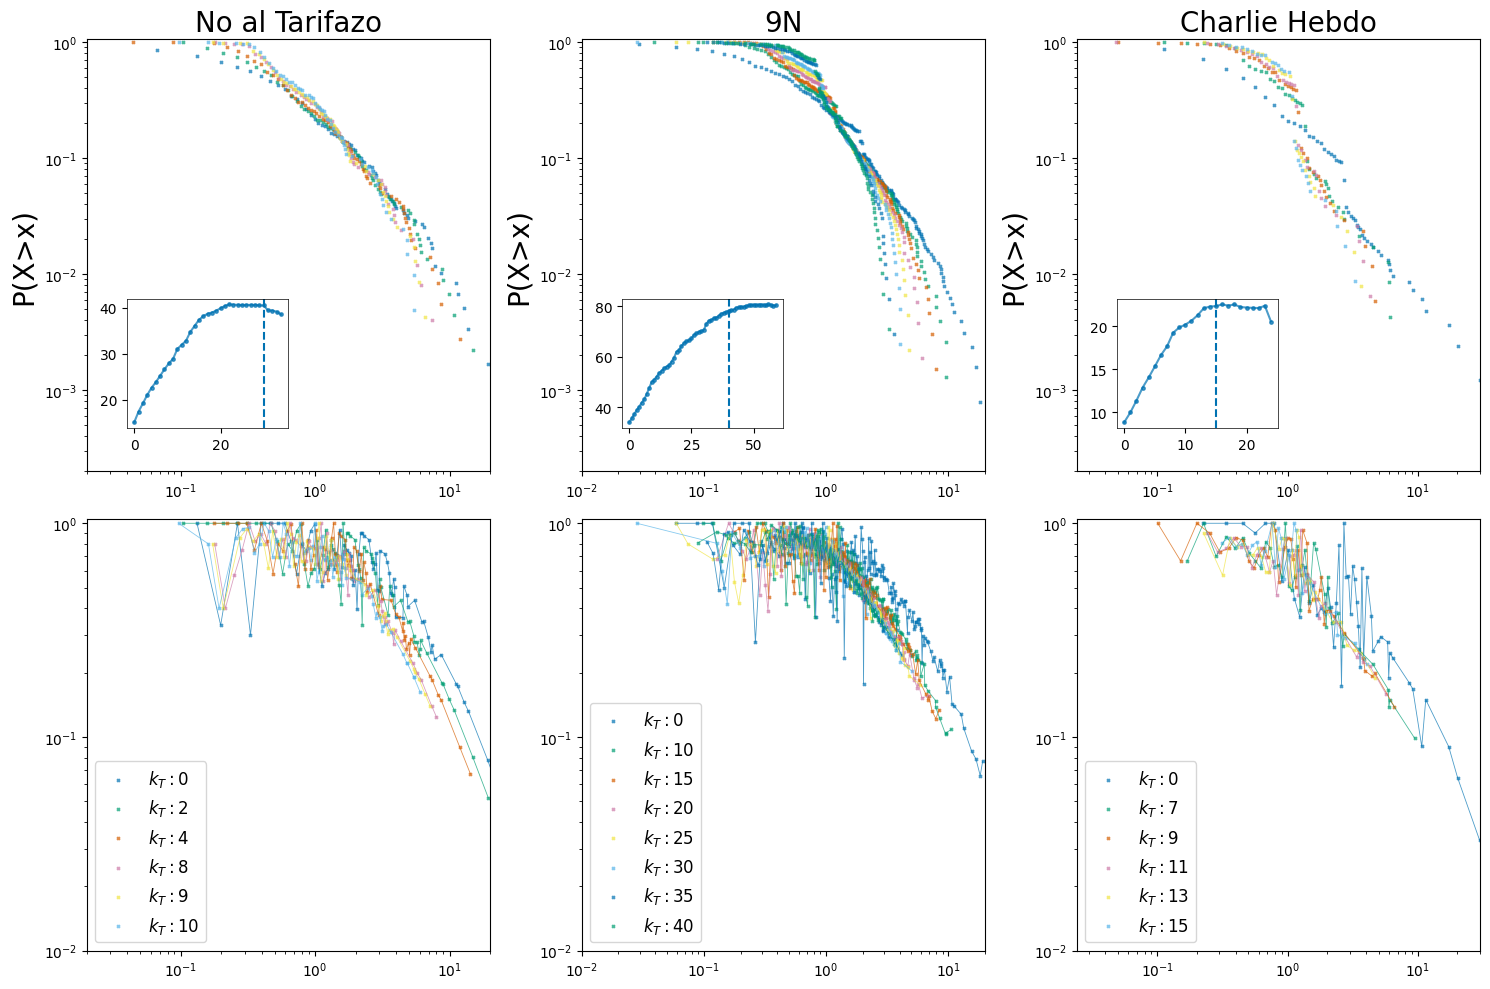

In [7]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_h = (0.02, 20)
xlim_9n_h = (0.01, 20)
xlim_ch_h = (0.024, 30)

plot_pdf(axs[0], arr_ccdf_points_nat_h, arr_kt_plot_nat_h, title="No al Tarifazo", ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_h)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_h, limit_kt_nat_h, axvline=critical_kt_nat_h)

plot_pdf(axs[1], arr_ccdf_points_9n_h, arr_kt_plot_9n_h, title="9N", ylim=(0.0002, 1.05), xlim=xlim_9n_h)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_h, limit_kt_9n_h, axvline=critical_kt_9n_h)

plot_pdf(axs[2], arr_ccdf_points_ch_h, arr_kt_plot_ch_h, title="Charlie Hebdo", ylim=(0.0002, 1.05), xlim=xlim_ch_h)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_h, limit_kt_ch_h, axvline=critical_kt_ch_h)


plot_clust_ss(axs[3], arr_kt_plot_nat_h, dict_norm_int_deg_nat_h, xlim=xlim_nat_h, ylim=(0.01, 1.05))
plot_clust_ss(axs[4], arr_kt_plot_9n_h, dict_norm_int_deg_9n_h, xlim=xlim_9n_h, ylim=(0.01, 1.05))
plot_clust_ss(axs[5], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h, xlim=xlim_ch_h, ylim=(0.01, 1.05))

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_hashtag.png")
plt.show()

## Grafos Filtrados

### Creación de los grafos filtrados

In [8]:
# Threshold empleado para cada manifestacion
umbral_nat = 3
umbral_9n = 5
umbral_ch = 3

# CREACIÓN DE LOS GRAFOS FILTRADOS
write_filtered_graph("nat", HORA_CRITICA_NAT, umbral_nat, graphs_folder, hour_window_nat)
write_filtered_graph("9n", HORA_CRITICA_9N, umbral_9n, graphs_folder, hour_window_9n)
write_filtered_graph("ch", HORA_CRITICA_CH, umbral_ch, graphs_folder, hour_window_ch)

Grafo nat:429624  (umbral 3) reducido a 19.16 % en nodos y  16.85 % en aristas.
Grafo 9n:437037  (umbral 5) reducido a 12.58 % en nodos y  7.1 % en aristas.
Grafo ch:394717  (umbral 3) reducido a 13.31 % en nodos y  7.4 % en aristas.


In [9]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200
dict_hora_nat_f = get_dict_hora_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_nat)
dict_hora_9n_f = get_dict_hora_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_9n)
dict_hora_ch_f = get_dict_hora_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_ch)

 19%|█▉        | 38/200 [00:00<00:00, 11844.79it/s]


### Autosimilitud de redes filtradas y Resultados en otras ventanas temporales diferentes a la crítica

In [10]:
limit_kt_nat_f = 35
limit_kt_9n_f = 60
limit_kt_ch_f = 30

critical_kt_nat_f = 10
critical_kt_9n_f = 18
critical_kt_ch_f = 5

arr_kt_plot_nat_f = [0,2,4,6,8,10]
arr_kt_plot_9n_f = [0,3,6,9,12,15,18]
arr_kt_plot_ch_f = [0,1,2,3,4,5]


In [11]:
plfit_nat_f, arr_pdf_points_nat_f, arr_ccdf_points_nat_f = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f, thresh_filt=umbral_nat, norm=True, read=False)
plfit_9n_f, arr_pdf_points_9n_f, arr_ccdf_points_9n_f = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n_f, thresh_filt=umbral_9n, norm=True, read=False)
plfit_ch_f, arr_pdf_points_ch_f, arr_ccdf_points_ch_f = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_f, thresh_filt=umbral_ch, norm=True, read=False)

100%|██████████| 6/6 [00:00<00:00, 853.98it/s]


Calculating best minimal value for power law fit


100%|██████████| 7/7 [00:00<00:00, 541.55it/s]


Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 2381.77it/s]

Calculating best minimal value for power law fit


In [12]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_f, dict_norm_int_deg_nat_f = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_nat)
dict_thres_avg_clust_9n_f, dict_norm_int_deg_9n_f = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n)
dict_thres_avg_clust_ch_f, dict_norm_int_deg_ch_f = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)

  0%|          | 0/500 [00:00<?, ?it/s]

  8%|▊         | 38/500 [00:00<00:00, 1617.55it/s]


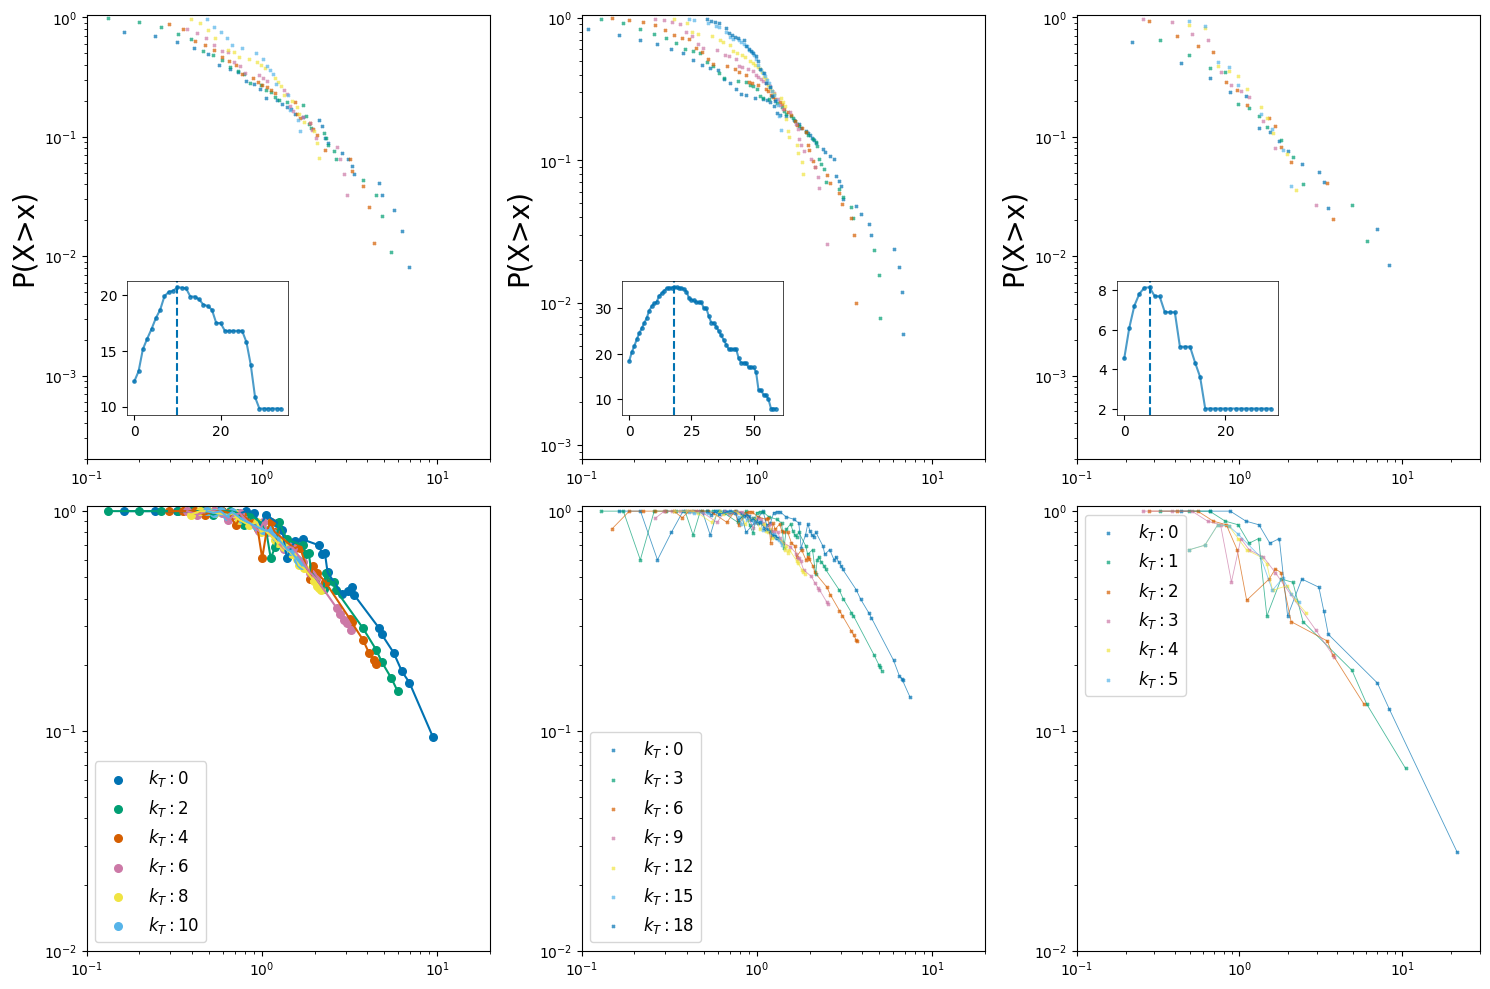

In [13]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_f = (0.1, 20)
xlim_9n_f = (0.1, 20)
xlim_ch_f = (0.1, 30)

plot_pdf(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_f)
ax6_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax6_inset, dict_hora_nat_f, limit_kt_nat_f, axvline=critical_kt_nat_f)

plot_pdf(axs[1], arr_ccdf_points_9n_f, arr_kt_plot_9n_f, ylim=(0.0008, 1.05), xlim=xlim_9n_f)
ax7_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax7_inset, dict_hora_9n_f, limit_kt_9n_f, axvline=critical_kt_9n_f)

plot_pdf(axs[2], arr_ccdf_points_ch_f, arr_kt_plot_ch_f, ylim=(0.0002, 1.05), xlim=xlim_ch_f)
ax8_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax8_inset, dict_hora_ch_f, limit_kt_ch_f, axvline=critical_kt_ch_f)


plot_clust_ss(axs[3], arr_kt_plot_nat_f, dict_norm_int_deg_nat_f, xlim=xlim_nat_f, ylim=(0.01, 1.05), loc="lower left", linewidth=1.5, s=30, marker="o", alpha=1)
plot_clust_ss(axs[4], arr_kt_plot_9n_f, dict_norm_int_deg_9n_f, xlim=xlim_9n_f, ylim=(0.01, 1.05))
plot_clust_ss(axs[5], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f, xlim=xlim_ch_f, ylim=(0.01, 1.05))


plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_filtered.png")
plt.show()

## Grafos otras horas NO filtradas nat

In [14]:
otras_horas_nat = ["429552", "429576", "429600", "429624", "429648", "429672", "429696", "429636"]

limit_kt_nat_o = 60
arr_kt_plot_nat_o = [0,2,4,6,8,10]


In [15]:
arr_dicts_avg_clust_nat_o = []
arr_dicts_norm_int_deg_nat_o = []
arr_ccdfs_points_nat_o = []
arr_dicts_hora_nat_o = []
arr_dicts_thres_avg_clust_nat_o = []
for hora in otras_horas_nat:

	dict_thres_avg_clust_nat_o, dict_norm_int_deg_nat_o = calc_self_sim(hora, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="h")
	plfit_nat_o, arr_pdf_points_nat_o, arr_ccdf_points_nat_o = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="h", arr_kt=arr_kt_plot_nat_o,read=False, exp=False, norm=True)
	dict_hora_nat_o = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

	arr_dicts_avg_clust_nat_o.append(dict_thres_avg_clust_nat_o)
	arr_dicts_norm_int_deg_nat_o.append(dict_norm_int_deg_nat_o)
	arr_ccdfs_points_nat_o.append(arr_ccdf_points_nat_o)
	arr_dicts_hora_nat_o.append(dict_hora_nat_o)

 19%|█▉        | 97/500 [00:00<00:00, 743.97it/s]


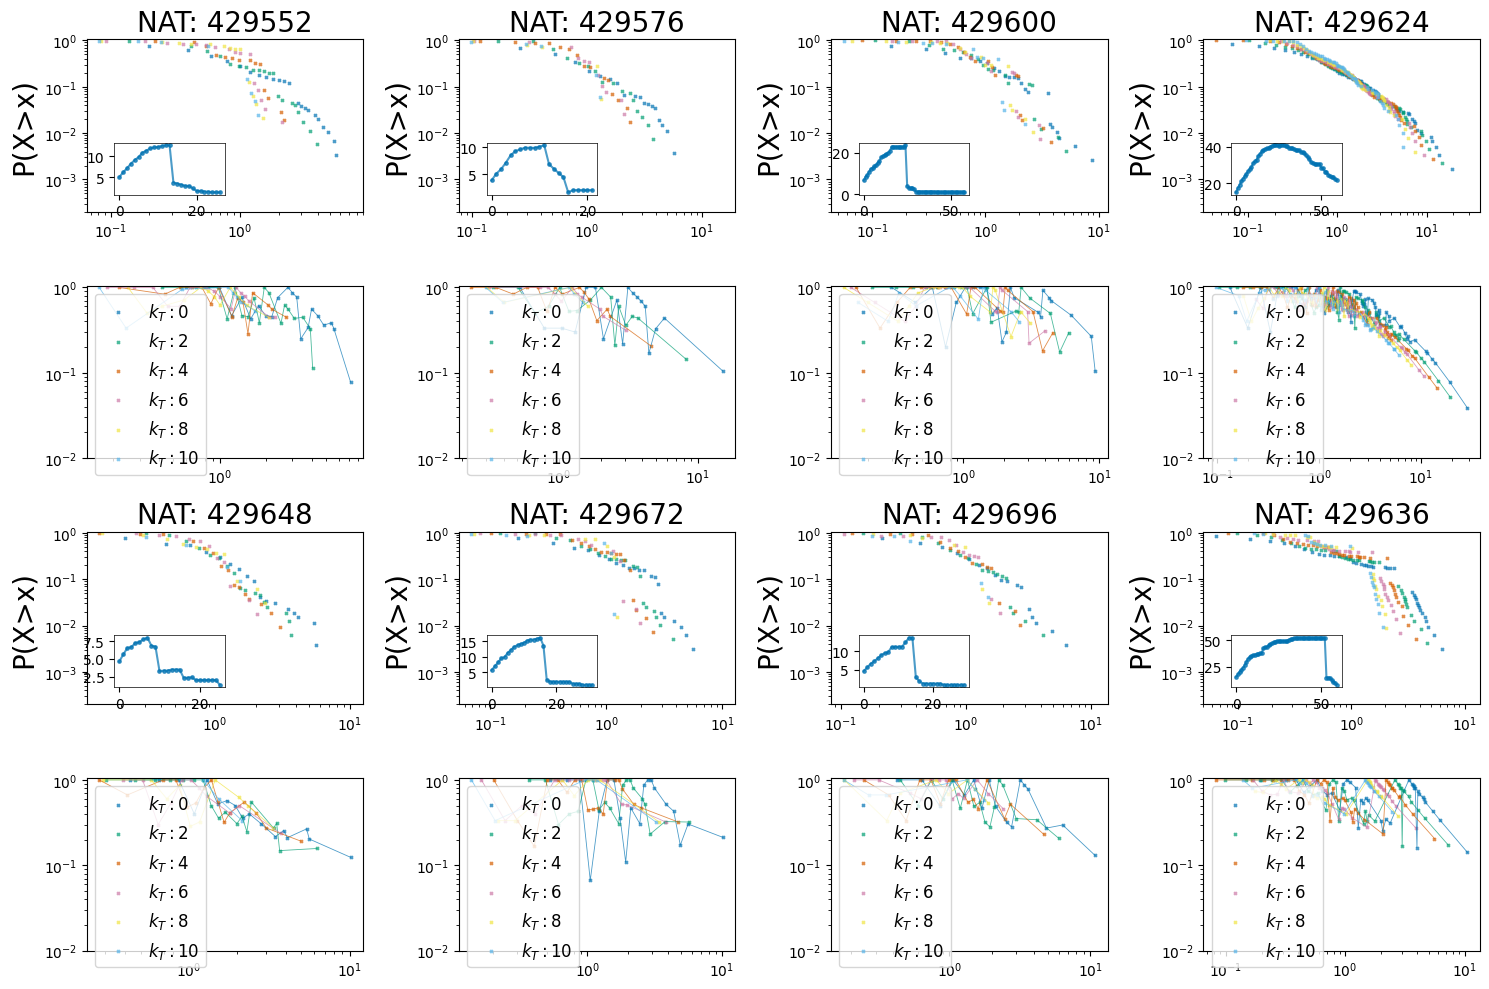

In [16]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(4, 4)
fig.set_size_inches(15,10)

xlim_nat_o = (0.1, 20)
for i, rax in enumerate(axs[::2]):
	index = i*2
	for j, ax in enumerate(rax):
		plot_pdf(axs[index][j], arr_ccdfs_points_nat_o[i*len(rax)+j], arr_kt_plot_nat_o, ylabel="P(X>x)", ylim=(0.0002, 1.05),  title=f"NAT: {otras_horas_nat[i*len(rax)+j]}")
		ax_inset = axs[index][j].inset_axes([0.1, 0.1, 0.4, 0.3])
		plot_avg_deg(ax_inset, arr_dicts_hora_nat_o[i*len(rax)+j], limit_kt_nat_o)
		plot_clust_ss(axs[index+1][j], arr_kt_plot_nat_o, arr_dicts_norm_int_deg_nat_o[i*len(rax)+j], ylim=(0.01, 1.05))

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_otras_horas.png")
plt.show()

He probado a filtrarlos, pero en la mayoría de casos, se tratan de grafos tan pequeños que no hay valores para plotear

### Redes filtradas

In [17]:
arr_kt_plot_nat_d = [0,1,2,4,6,8,10]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora, filtered=True, umbral=umbral_nat)
	filename_input = f"disparity_filter/puntos/{hora}_filt.csv"
	filename_output = f"disparity_filter/puntos/{hora}_filt_conf_all"
	backbone_confidence(filename_input, filename_output + '.csv')

100%|██████████| 1/1 [00:00<00:00,  2.74it/s]

123 753 disparity_filter/puntos/429624_filt.csv


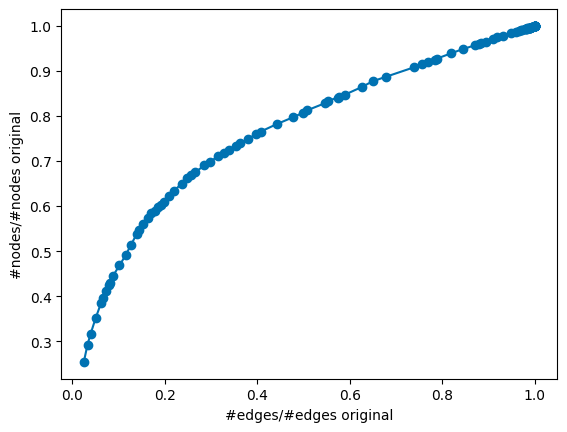

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos desde archivo
datos_f_d = np.loadtxt("disparity_filter/puntos/429624_filt_conf_all.csv")

x = datos_f_d[:, 3]  
y = datos_f_d[:, 1]  

plt.plot(x, y, marker='o')
#plt.axvline(x=0.8, color='red', linestyle='--')
plt.xlabel('#edges/#edges original')
plt.ylabel('#nodes/#nodes original')
plt.show()


In [19]:
arr_kt_plot_nat_f_d = [0,1,2,4,6,8,10]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora)
	filename_input = f"disparity_filter/puntos/{hora}_filt.csv"
	filename_output = f"disparity_filter/puntos/{hora}_filt_conf"
	backbone(filename_input, filename_output + '25.csv', wconfidence=0.25)


	G = nx.Graph()  # Usa nx.DiGraph() si necesitas que sea dirigido
	with open(f"disparity_filter/puntos/{hora}_filt_conf25.csv", "r") as f:
		for line in f:
			source, target, weight = line.strip().split()
			G.add_edge(int(source), int(target), weight=float(weight))

	nx.write_gexf(G, f"graphs/nodes_disparity/nat/1/{hora}_filt.gexf")

"""	dict_hora_nat_f_d = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)

	plfit_nat_f_d, arr_pdf_points_nat_f_d, arr_ccdf_points_nat_f_d = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f_d, norm=True)

	dict_thres_avg_clust_nat_f_d, dict_norm_int_deg_nat_f_d = calc_self_sim(hora, 200, "nat/" + str(hour_window_nat) + '/', mode="d")"""
#TBD Adaptar estas funciones (si precisa y tiene sentido para poder emplear el filtrado por disparidad-->Re enrutar adecuadamente el path)


100%|██████████| 1/1 [00:00<00:00, 10.71it/s]

642 4470 disparity_filter/puntos/429624.csv
fraction of weight in backbone= 0.9949396652393928 disparity_filter/puntos/429624_filt_conf25.csv


'\tdict_hora_nat_f_d = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)\n\n\tplfit_nat_f_d, arr_pdf_points_nat_f_d, arr_ccdf_points_nat_f_d = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + \'/\', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f_d, norm=True)\n\n\tdict_thres_avg_clust_nat_f_d, dict_norm_int_deg_nat_f_d = calc_self_sim(hora, 200, "nat/" + str(hour_window_nat) + \'/\', mode="d")'

## Exponential binning

### Redes originales

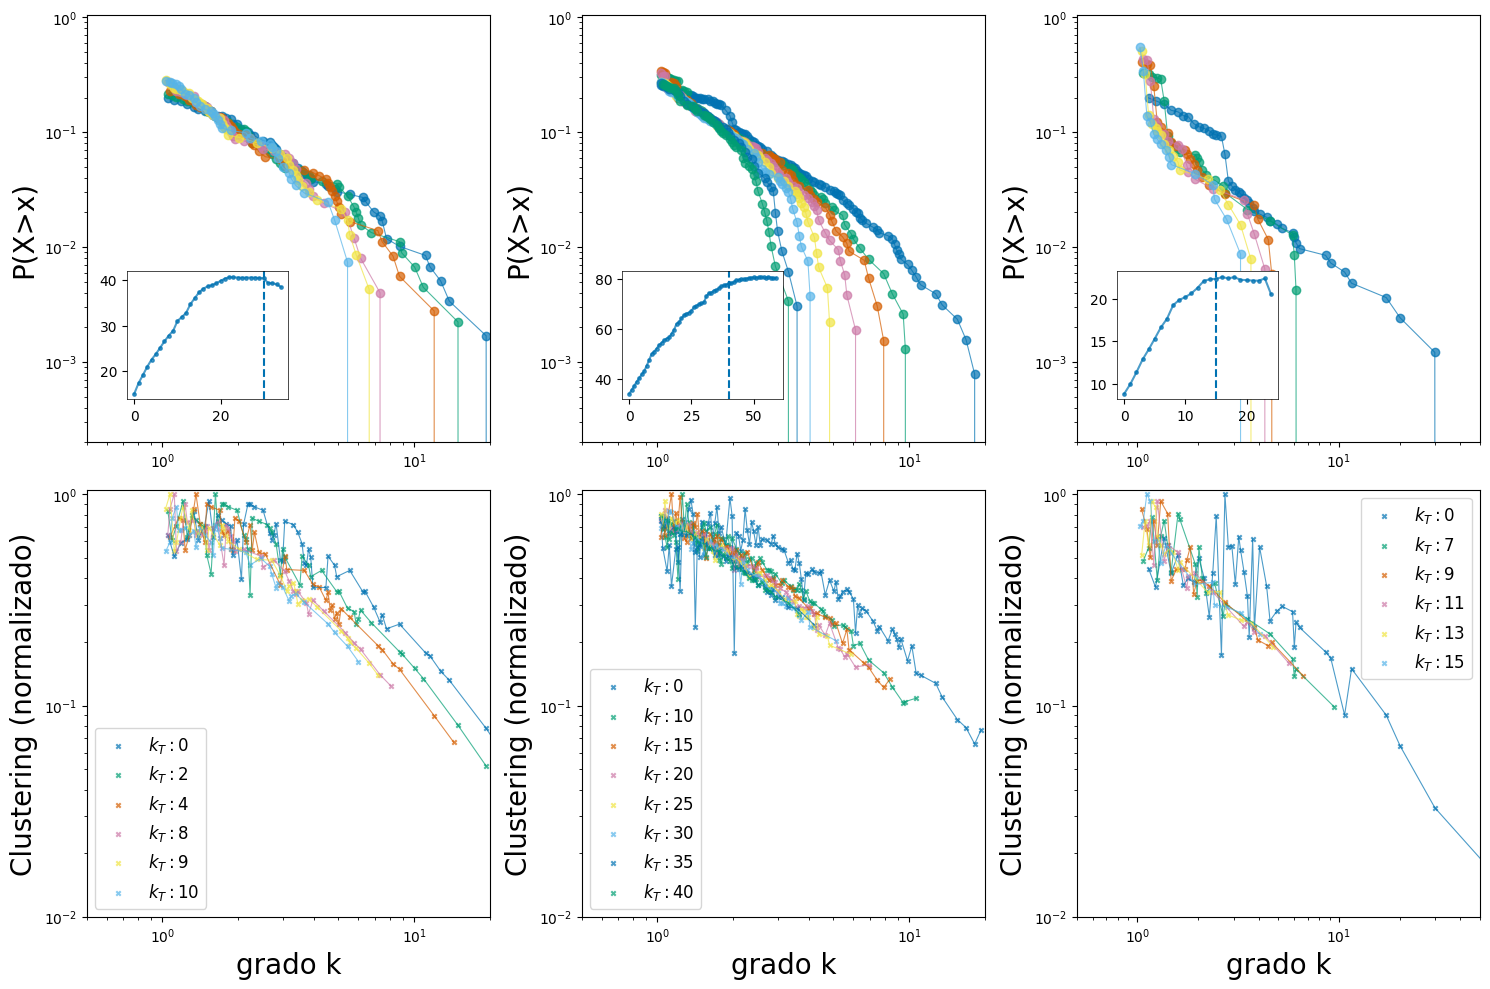

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_h_e = (0.5, 20)
xlim_9n_h_e = (0.5, 20)
xlim_ch_h_e = (0.5, 50)

plot_pdf_expbin(axs[0], arr_ccdf_points_nat_h, arr_kt_plot_nat_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_h, limit_kt_nat_h, axvline=critical_kt_nat_h)

plot_pdf_expbin(axs[1], arr_ccdf_points_9n_h, arr_kt_plot_9n_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_9n_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_h, limit_kt_9n_h, axvline=critical_kt_9n_h)

plot_pdf_expbin(axs[2], arr_ccdf_points_ch_h, arr_kt_plot_ch_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_ch_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_h, limit_kt_ch_h, axvline=critical_kt_ch_h)


plot_clust_ss_expbin(axs[3], arr_kt_plot_nat_h, dict_norm_int_deg_nat_h,
                     aa=1.02, xlim=xlim_nat_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="grado k")

plot_clust_ss_expbin(axs[4], arr_kt_plot_9n_h, dict_norm_int_deg_9n_h,
                     aa=1.02, xlim=xlim_9n_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="grado k")

plot_clust_ss_expbin(axs[5], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h,
                     aa=1.02, xlim=xlim_ch_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="grado k")


plt.tight_layout()
plt.savefig(plots_folder + "self_sim_exponential.png")
plt.show()

### Redes originales otras horas

In [21]:
otras_horas_nat = ["429600", "429614", "429619", "429624", "429628", "429648", "429696", "429636"]

limit_kt_nat_o_e = 60
arr_kt_plot_nat_o_e = [0,2,4,6,8,10]


In [22]:
arr_dicts_avg_clust_nat_o_e = []
arr_dicts_norm_int_deg_nat_o_e = []
arr_ccdfs_points_nat_o_e = []
arr_dicts_hora_nat_o_e = []
arr_dicts_thres_avg_clust_nat_o_e = []
for hora in otras_horas_nat:

	dict_thres_avg_clust_nat_o_e, dict_norm_int_deg_nat_o_e = calc_self_sim(hora, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="h")
	plfit_nat_o_e, arr_pdf_points_nat_o_e, arr_ccdf_points_nat_o_e = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="h", arr_kt=arr_kt_plot_nat_o_e,read=False, exp=False, norm=True)
	dict_hora_nat_o_e = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

	arr_dicts_avg_clust_nat_o_e.append(dict_thres_avg_clust_nat_o_e)
	arr_dicts_norm_int_deg_nat_o_e.append(dict_norm_int_deg_nat_o_e)
	arr_ccdfs_points_nat_o_e.append(arr_ccdf_points_nat_o_e)
	arr_dicts_hora_nat_o_e.append(dict_hora_nat_o_e)

 19%|█▉        | 97/500 [00:00<00:00, 766.20it/s]


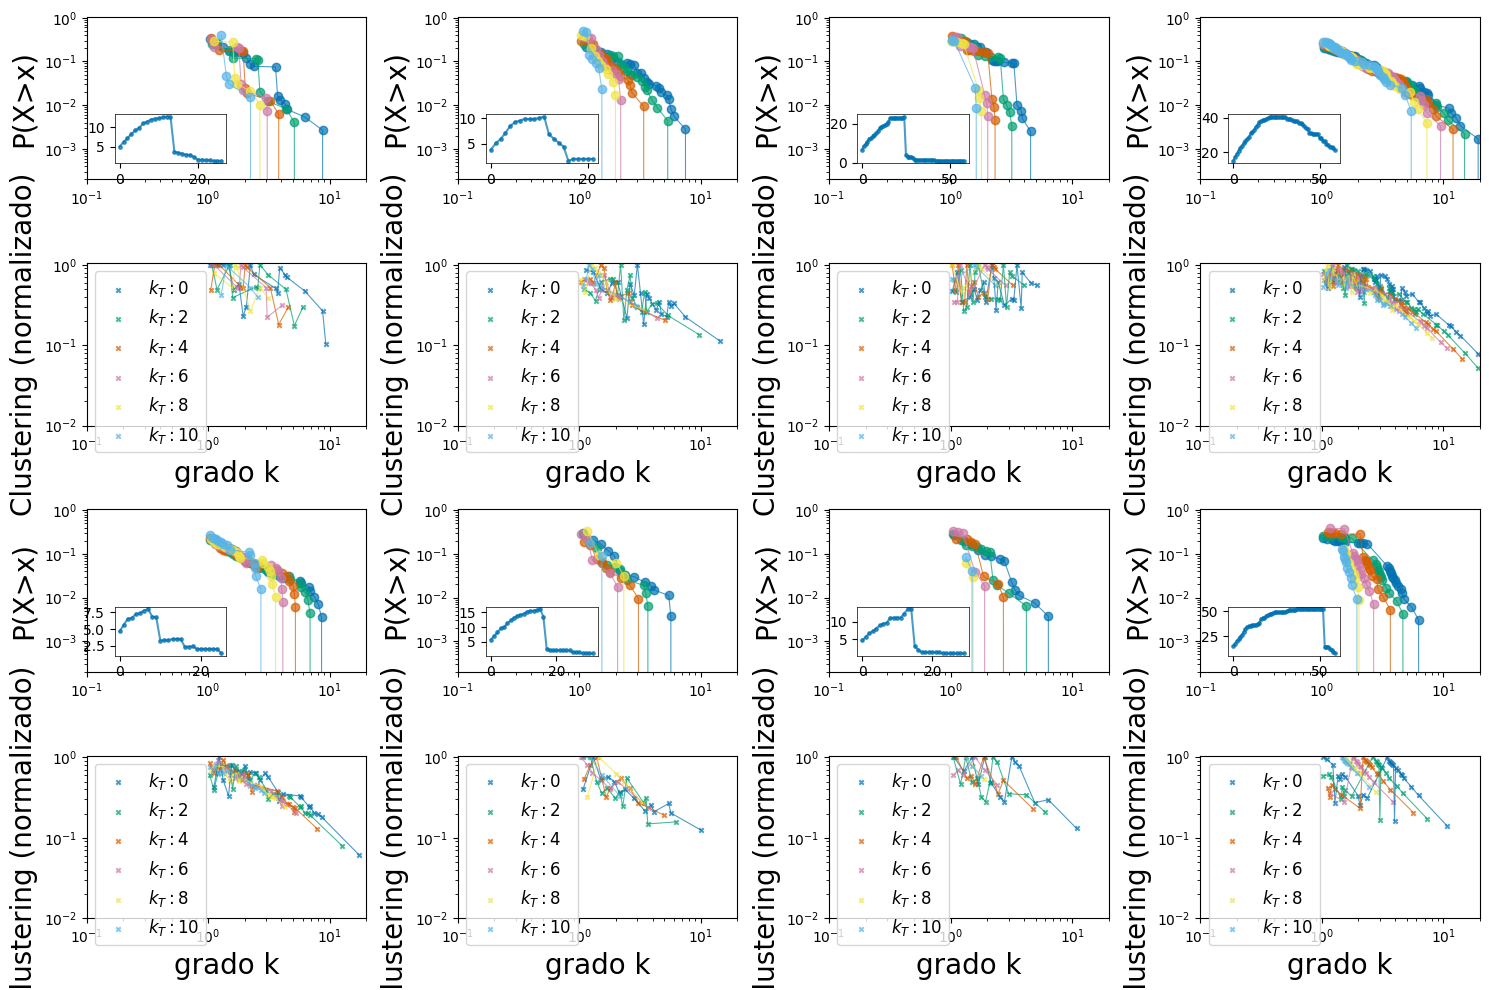

In [ ]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(4, 4)
fig.set_size_inches(15,10)

xlim_nat_o_e = (0.1, 20)
for i, rax in enumerate(axs[::2]):
	index = i*2
	for j, ax in enumerate(rax):
		plot_pdf_expbin(axs[index][j], arr_ccdfs_points_nat_o_e[i*len(rax)+j], arr_kt_plot_nat_o_e,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_o_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
		#plot_pdf(axs[index][j], arr_ccdfs_points_nat_o[i*len(rax)+j], arr_kt_plot_nat_o, ylabel="P(X>x)", ylim=(0.0002, 1.05),  title=f"NAT: {otras_horas_nat[i*len(rax)+j]}")
		ax_inset = axs[index][j].inset_axes([0.1, 0.1, 0.4, 0.3])
		plot_avg_deg(ax_inset, arr_dicts_hora_nat_o[i*len(rax)+j], limit_kt_nat_o)
		plot_clust_ss_expbin(axs[index+1][j], arr_kt_plot_nat_o_e, arr_dicts_norm_int_deg_nat_o_e[i*len(rax)+j],
                     aa=1.02, xlim=xlim_nat_o_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="grado k")
		

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_otras_horas_exp.png")
plt.show()

#["429600", "429614", "429619", "429624", "429628", "429648", "429696", "429636"]

In [30]:
plfit_9n_f, arr_pdf_points_9n_f, arr_ccdf_points_9n_f = calc_degree_distribution(str(int(HORA_CRITICA_9N)+24), "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n_f, thresh_filt=umbral_9n, norm=True, read=False)
dict_thres_avg_clust_9n_f, dict_norm_int_deg_9n_f = calc_self_sim(str(int(HORA_CRITICA_9N)+24), MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n)


100%|██████████| 7/7 [00:00<00:00, 807.55it/s]


Calculating best minimal value for power law fit


 18%|█▊        | 90/500 [00:00<00:01, 407.90it/s]


### Redes filtradas

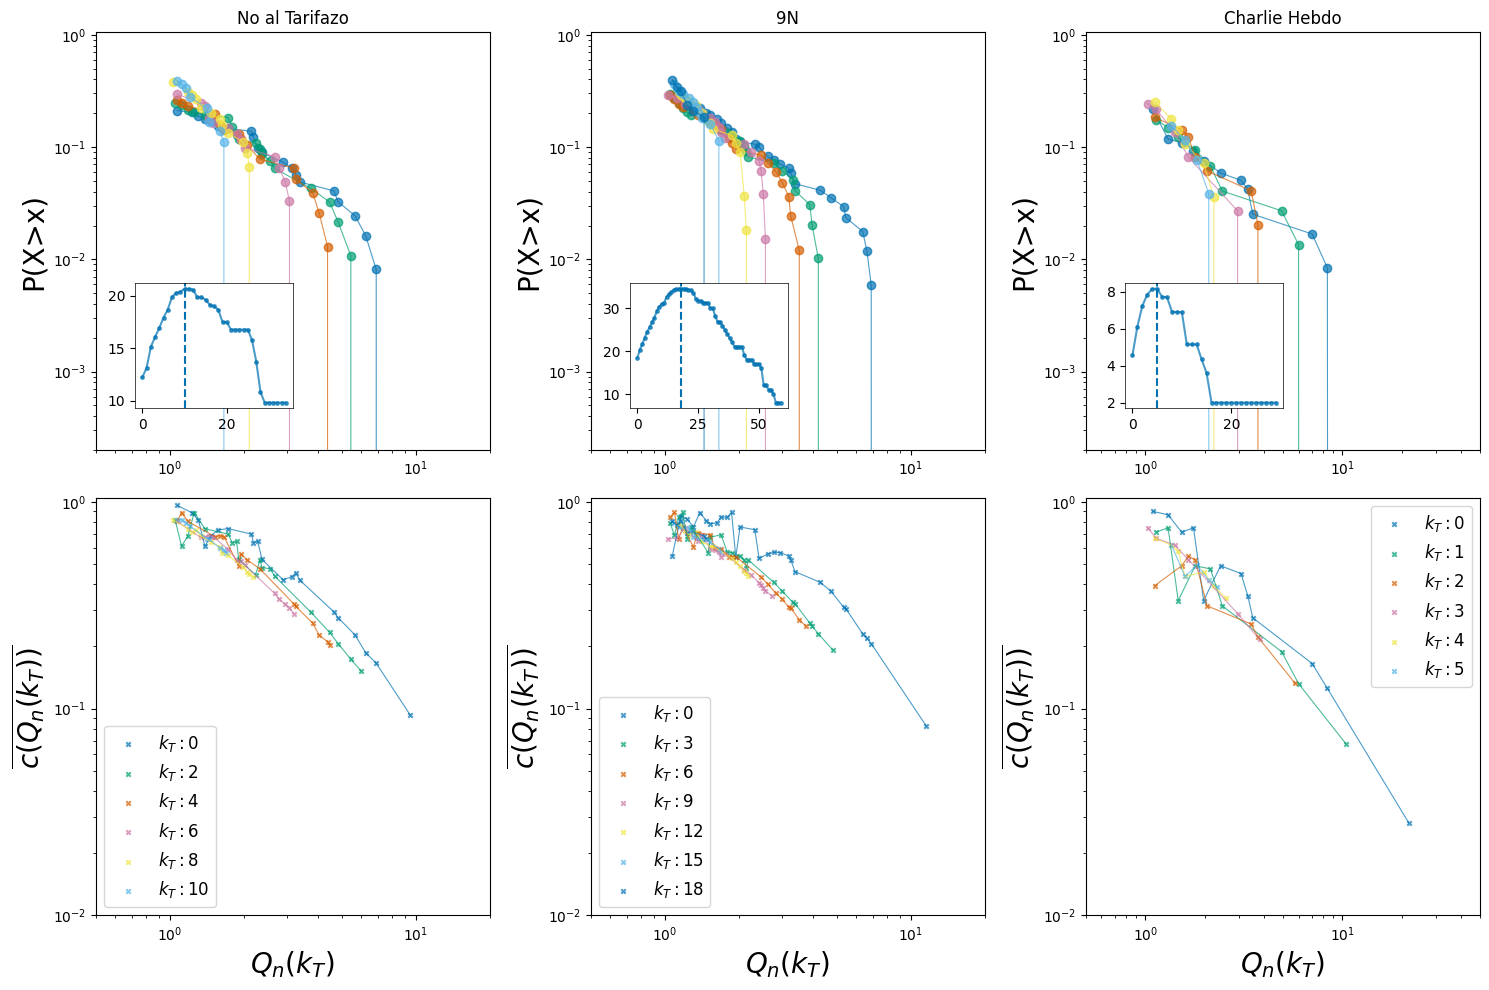

In [37]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_f_e = (0.5, 20)
xlim_9n_f_e = (0.5, 20)
xlim_ch_f_e = (0.5, 50)

plot_pdf_expbin(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_f, limit_kt_nat_f, axvline=critical_kt_nat_f)

plot_pdf_expbin(axs[1], arr_ccdf_points_9n_f, arr_kt_plot_9n_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_9n_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_f, limit_kt_9n_f, axvline=critical_kt_9n_f)

plot_pdf_expbin(axs[2], arr_ccdf_points_ch_f, arr_kt_plot_ch_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_ch_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_f, limit_kt_ch_f, axvline=critical_kt_ch_f)


plot_clust_ss_expbin(axs[3], arr_kt_plot_nat_f, dict_norm_int_deg_nat_f,
                     aa=1.02, xlim=xlim_nat_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="$Q_n(k_T)$")

plot_clust_ss_expbin(axs[4], arr_kt_plot_9n_f, dict_norm_int_deg_9n_f,
                     aa=1.02, xlim=xlim_9n_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="$Q_n(k_T)$")

plot_clust_ss_expbin(axs[5], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f,
                     aa=1.02, xlim=xlim_ch_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="$Q_n(k_T)$")

axs[0].set_title("No al Tarifazo")
axs[1].set_title("9N")
axs[2].set_title("Charlie Hebdo")

plt.tight_layout()
plt.savefig(plots_folder + "self_sim_exponential_filtered.png")
plt.show()

# Finding the Critical Time Window (CTW)

In [4]:
otras_horas_nat = [str(hor) for hor in range(429576, 429672)]
registros = []  # aquí acumulamos las filas (hora, clave_max)

for i in otras_horas_nat:
	source_path = f"graphs/nodes_hashtag/nat/{hour_window_nat}/{i}.gexf"
	out_path =  f"epsilon_sq/nat/{i}/{i}.edge"
	if not os.path.exists(f"./epsilon_sq/nat/{i}/"):
		os.makedirs(f"./epsilon_sq/nat/{i}/")
	gexf_a_edge(source_path, out_path)    
	# Diccionario y clave con máximo valor
	d = get_dict_hora_kt("nat", i, hour_window=hour_window_nat)
	clave_max = max(d, key=d.get) if d else None  # None si el dict está vacío

	# Guardar registro
	registros.append({"hora": i, "clave_max": clave_max})

# Construir DataFrame final (dos columnas)
df_max = pd.DataFrame(registros, columns=["hora", "clave_max"])
df_max.to_csv("./epsilon_sq/nat/kts.csv")


  0%|          | 0/200 [00:00<?, ?it/s]

  9%|▉         | 18/200 [00:00<00:00, 3069.75it/s]


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import datetime as dt

def find_col(df, candidates):
    for cand in candidates:
        for col in df.columns:
            if col.strip() == cand.strip():
                return col
    return None


def rolling_mean(series, window):
    s = pd.to_numeric(series, errors="coerce")
    return s.rolling(window=window, min_periods=1).mean()

def plot_ma_if_exists(df, N, axes, ycol, label):
    if ycol is not None and ycol in df:
        y_ma = rolling_mean(df[ycol], N)
		
        axes[0].plot(
            x, y_ma,
            marker=None,            # no puntos: solo la media móvil
            linewidth=1.8,
            label=f"{label} (MA{N})",
        )

Calculando el anidamiento y modularidad de nat con criterio: h


100%|██████████| 260/260 [00:00<00:00, 1582756.23it/s]


Calculando el anidamiento y modularidad de nat con criterio: b


100%|██████████| 260/260 [00:00<00:00, 1421797.97it/s]
/tmp/ipykernel_48670/3835939869.py:69: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green", label=f"Critical No al Tarifazo\nhour time{dt.datetime.utcfromtimestamp(int(HORA_CRITICA_NAT)*3600).strftime('%Y-%m-%d %H:%M')}")
/tmp/ipykernel_48670/3835939869.py:89: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


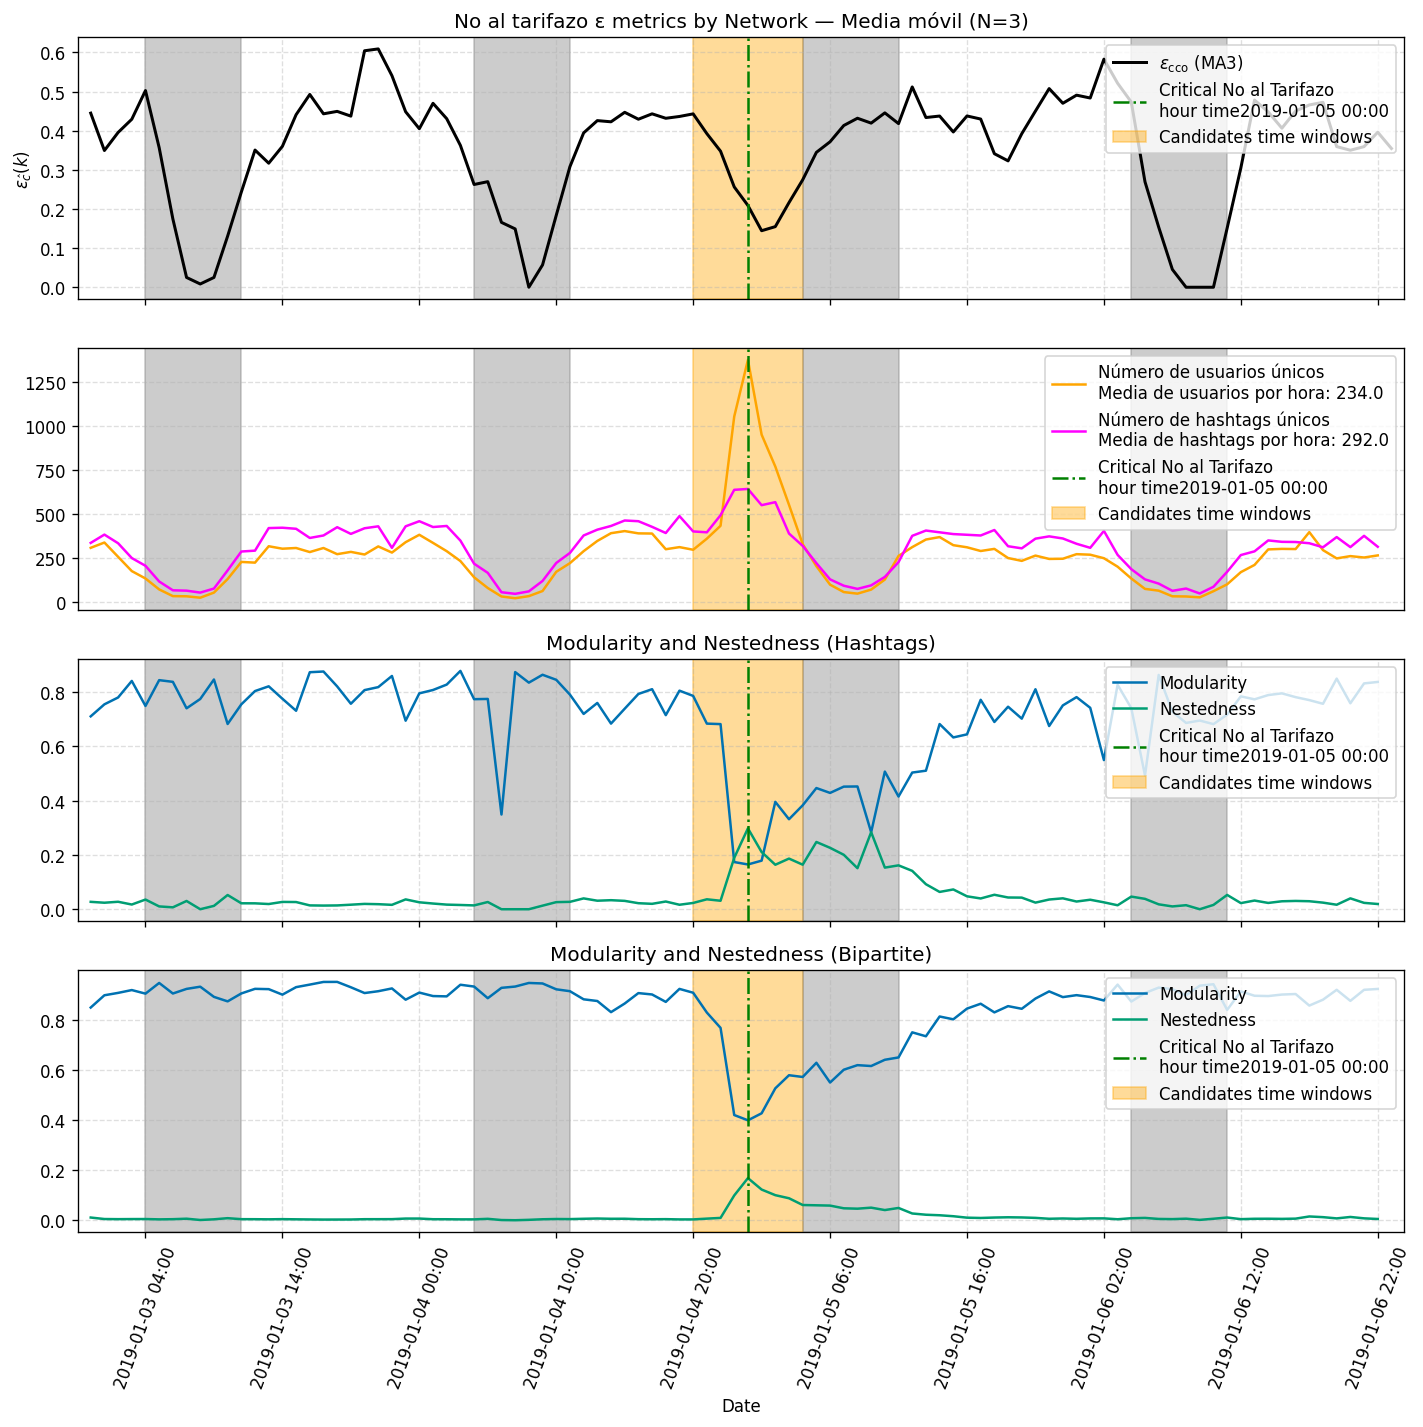

In [ ]:

N = 3  # ventana de la media móvil (últimos N puntos)
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 12), dpi=120)

df = pd.read_csv("epsilon_sq/nat/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/nat/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
    r"$\epsilon_{\ccdf}$": "eps_ccdf",
    r"$\epsilon_{\knn}$":  "eps_knn",
    r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

df_nat = read_data("nat", datasets_folder=datasets_folder)

hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]


num_users_nat, num_hashtags_nat = get_num_users_hashtags(df_nat, hour_window=hour_window_nat)
plot_num_users_hashtags(axes[1], hour_nat, hour_window_nat, num_users_nat, num_hashtags_nat, inicio=45, final=140, legend=False)

hour_sort_nat_h, mod_sort_nat_h, nest_sort_nat_h = get_mod_nest_coefficient("nat", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)
plot_mod_nestedness(axes[2], hour_nat, hour_window_nat, mod_sort_nat_h, nest_sort_nat_h, inicio=45, final=140, legend=False, tick_split=30, HORA_CRITICA=None)


hour_sort_nat_b, mod_sort_nat_b, nest_sort_nat_b = get_mod_nest_coefficient("nat", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)
plot_mod_nestedness(axes[3], hour_nat, hour_window_nat, mod_sort_nat_b, nest_sort_nat_b, inicio=45, final=140, legend=False, tick_split=30, HORA_CRITICA=None)

def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label} (MA{N})",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for ax in axes:
	ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green", label=f"Critical No al Tarifazo\nhour time{dt.datetime.utcfromtimestamp(int(HORA_CRITICA_NAT)*3600).strftime('%Y-%m-%d %H:%M')}")
	
	ax.axvspan(429620, 429628, color='orange', alpha=0.4, label="Candidates time windows")
	ax.legend(loc="upper right")
	
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	#from 00:01 to 8:00
	ax.axvspan(429580, 429587, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(429604, 429611, color='gray', alpha=0.4)
	ax.axvspan(429628, 429635, color='gray', alpha=0.4)
	ax.axvspan(429652, 429659, color='gray', alpha=0.4)

axes[0].set_title(f"No al tarifazo ε metrics by Network — Media móvil (N={N})")
axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
axes[2].set_title("Modularity and Nestedness (Hashtags)")
axes[3].set_title("Modularity and Nestedness (Bipartite)")
axes[3].set_xlabel("Date")
def horas_a_fecha(x_val, pos):
    # x_val es el número en el eje
    fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
    return fecha.strftime('%Y-%m-%d %H:%M')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
# Eje X menos cargado
axes[2].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[2].get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")



plt.tight_layout()
plt.show()


Calculando el anidamiento y modularidad de nat con criterio: b


100%|██████████| 260/260 [00:00<00:00, 1068089.17it/s]
/tmp/ipykernel_48670/702946985.py:62: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green", label=f"Critical No al Tarifazo\nhour time{dt.datetime.utcfromtimestamp(int(HORA_CRITICA_NAT)*3600).strftime('%Y-%m-%d %H:%M')}")


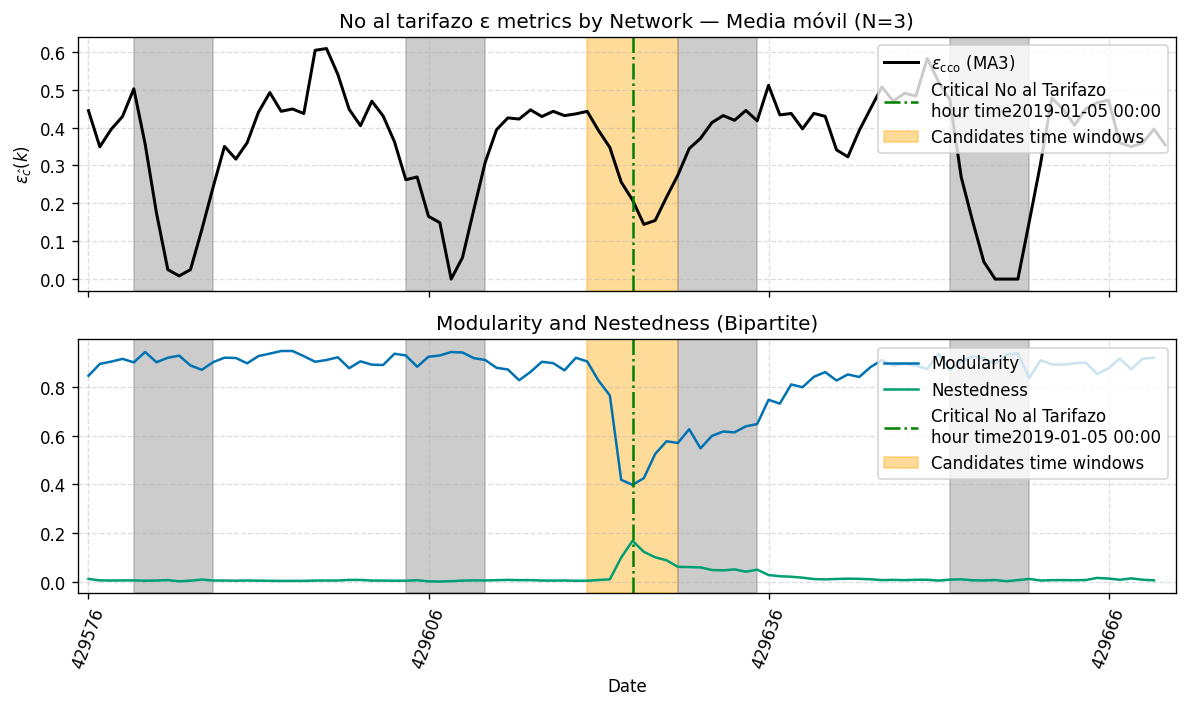

In [26]:

N = 3  # ventana de la media móvil (últimos N puntos)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6), dpi=120)

df = pd.read_csv("epsilon_sq/nat/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/nat/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
    r"$\epsilon_{\ccdf}$": "eps_ccdf",
    r"$\epsilon_{\knn}$":  "eps_knn",
    r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

df_nat = read_data("nat", datasets_folder=datasets_folder)

hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]


hour_sort_nat_b, mod_sort_nat_b, nest_sort_nat_b = get_mod_nest_coefficient("nat", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)
plot_mod_nestedness(axes[1], hour_nat, hour_window_nat, mod_sort_nat_b, nest_sort_nat_b, inicio=45, final=140, legend=False, tick_split=30, HORA_CRITICA=None)

def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label} (MA{N})",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for ax in axes:
	ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green", label=f"Critical No al Tarifazo\nhour time{dt.datetime.utcfromtimestamp(int(HORA_CRITICA_NAT)*3600).strftime('%Y-%m-%d %H:%M')}")
	
	ax.axvspan(429620, 429628, color='orange', alpha=0.4, label="Candidates time windows")
	ax.legend(loc="upper right")
	
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	#from 00:01 to 8:00
	ax.axvspan(429580, 429587, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(429604, 429611, color='gray', alpha=0.4)
	ax.axvspan(429628, 429635, color='gray', alpha=0.4)
	ax.axvspan(429652, 429659, color='gray', alpha=0.4)

axes[0].set_title(f"No al tarifazo ε metrics by Network — Media móvil (N={N})")
axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
axes[1].set_title("Modularity and Nestedness (Bipartite)")
axes[1].set_xlabel("Date")
def horas_a_fecha(x_val, pos):
    # x_val es el número en el eje
    fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
    return fecha.strftime('%Y-%m-%d %H:%M')

plt.tight_layout()
plt.show()


Calculando el anidamiento y modularidad de nat con criterio: h


100%|██████████| 260/260 [00:00<00:00, 975419.53it/s]
/tmp/ipykernel_48670/2575084247.py:54: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green", label=f"Critical No al Tarifazo\nhour time{dt.datetime.utcfromtimestamp(int(HORA_CRITICA_NAT)*3600).strftime('%Y-%m-%d %H:%M')}")
/tmp/ipykernel_48670/2575084247.py:73: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


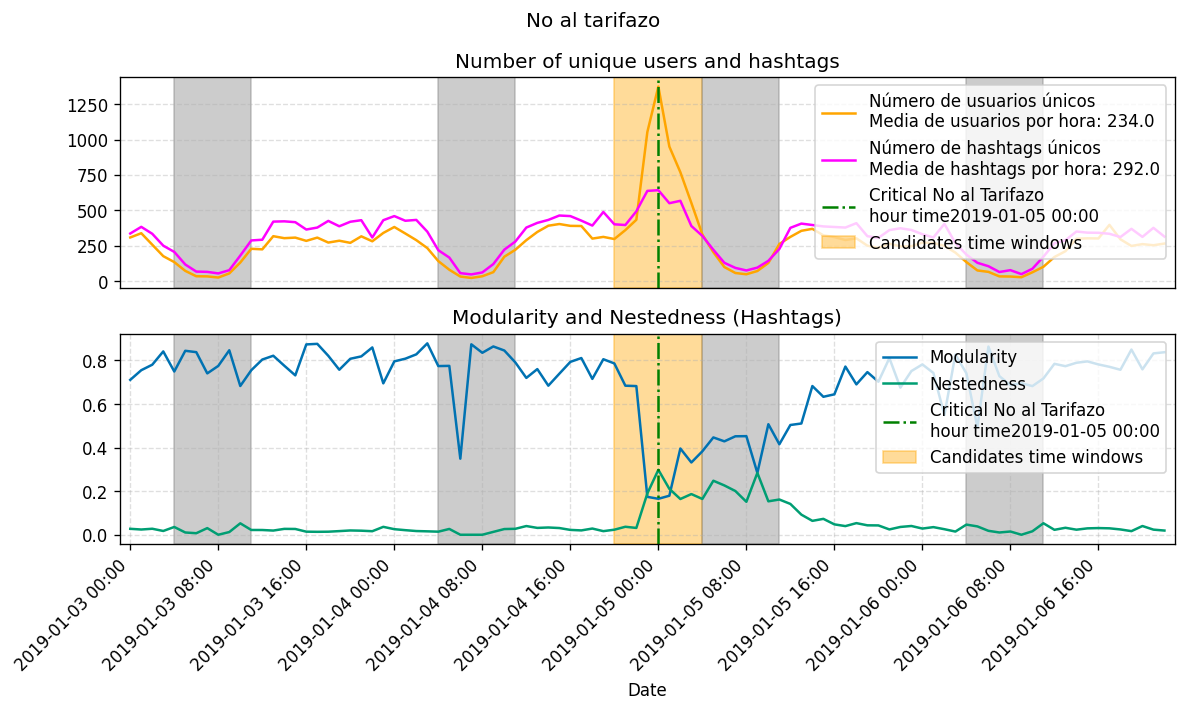

In [24]:

N = 3  # ventana de la media móvil (últimos N puntos)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6), dpi=120)

df = pd.read_csv("epsilon_sq/nat/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/nat/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
    r"$\epsilon_{\ccdf}$": "eps_ccdf",
    r"$\epsilon_{\knn}$":  "eps_knn",
    r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

df_nat = read_data("nat", datasets_folder=datasets_folder)

hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]


num_users_nat, num_hashtags_nat = get_num_users_hashtags(df_nat, hour_window=hour_window_nat)
plot_num_users_hashtags(axes[0], hour_nat, hour_window_nat, num_users_nat, num_hashtags_nat, inicio=45, final=140, legend=False)

hour_sort_nat_h, mod_sort_nat_h, nest_sort_nat_h = get_mod_nest_coefficient("nat", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_nat)
plot_mod_nestedness(axes[1], hour_nat, hour_window_nat, mod_sort_nat_h, nest_sort_nat_h, inicio=45, final=140, legend=False, tick_split=30, HORA_CRITICA=None)


for ax in axes:
	ax.axvline(int(HORA_CRITICA_NAT), linestyle="-.", color="green", label=f"Critical No al Tarifazo\nhour time{dt.datetime.utcfromtimestamp(int(HORA_CRITICA_NAT)*3600).strftime('%Y-%m-%d %H:%M')}")
	
	ax.axvspan(429620, 429628, color='orange', alpha=0.4, label="Candidates time windows")
	ax.legend(loc="upper right")
	
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	#from 00:01 to 8:00
	ax.axvspan(429580, 429587, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(429604, 429611, color='gray', alpha=0.4)
	ax.axvspan(429628, 429635, color='gray', alpha=0.4)
	ax.axvspan(429652, 429659, color='gray', alpha=0.4)
     
fig.suptitle("No al tarifazo")
axes[0].set_title("Number of unique users and hashtags")
axes[1].set_title("Modularity and Nestedness (Hashtags)")
axes[1].set_xlabel("Date")
def horas_a_fecha(x_val, pos):
    # x_val es el número en el eje
    fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
    return fecha.strftime('%Y-%m-%d %H:%M')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
# Eje X menos cargado
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[1].get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")



plt.tight_layout()
plt.show()


In [13]:
otras_horas_9n = [str(hor) for hor in range(int(HORA_CRITICA_9N)-72, int(HORA_CRITICA_9N)+72)]
registros = []  # aquí acumulamos las filas (hora, clave_max)

for i in otras_horas_9n:
	source_path = f"graphs/nodes_hashtag/9n/{hour_window_9n}/{i}.gexf"
	out_path =  f"epsilon_sq/9n/{i}/{i}.edge"
	if not os.path.exists(f"./epsilon_sq/9n/{i}/"):
		os.makedirs(f"./epsilon_sq/9n/{i}/")
	if os.path.exists(source_path):
		gexf_a_edge(source_path, out_path)    
		# Diccionario y clave con máximo valor
		d = get_dict_hora_kt("9n", i, hour_window=hour_window_9n)
		clave_max = max(d, key=d.get) if d else None  # None si el dict está vacío

		# Guardar registro
		registros.append({"hora": i, "clave_max": clave_max})

# Construir DataFrame final (dos columnas)
df_max = pd.DataFrame(registros, columns=["hora", "clave_max"])
df_max.to_csv("./epsilon_sq/9n/kts.csv")


 58%|█████▊    | 116/200 [00:00<00:00, 1082.17it/s]


Now we need to execute the script to compute epsilon values 

Calculando el anidamiento y modularidad de 9n con criterio: h


100%|██████████| 49/49 [00:00<00:00, 626588.10it/s]


Calculando el anidamiento y modularidad de 9n con criterio: b


100%|██████████| 49/49 [00:00<00:00, 380594.25it/s]
/tmp/ipykernel_48670/1712083939.py:94: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


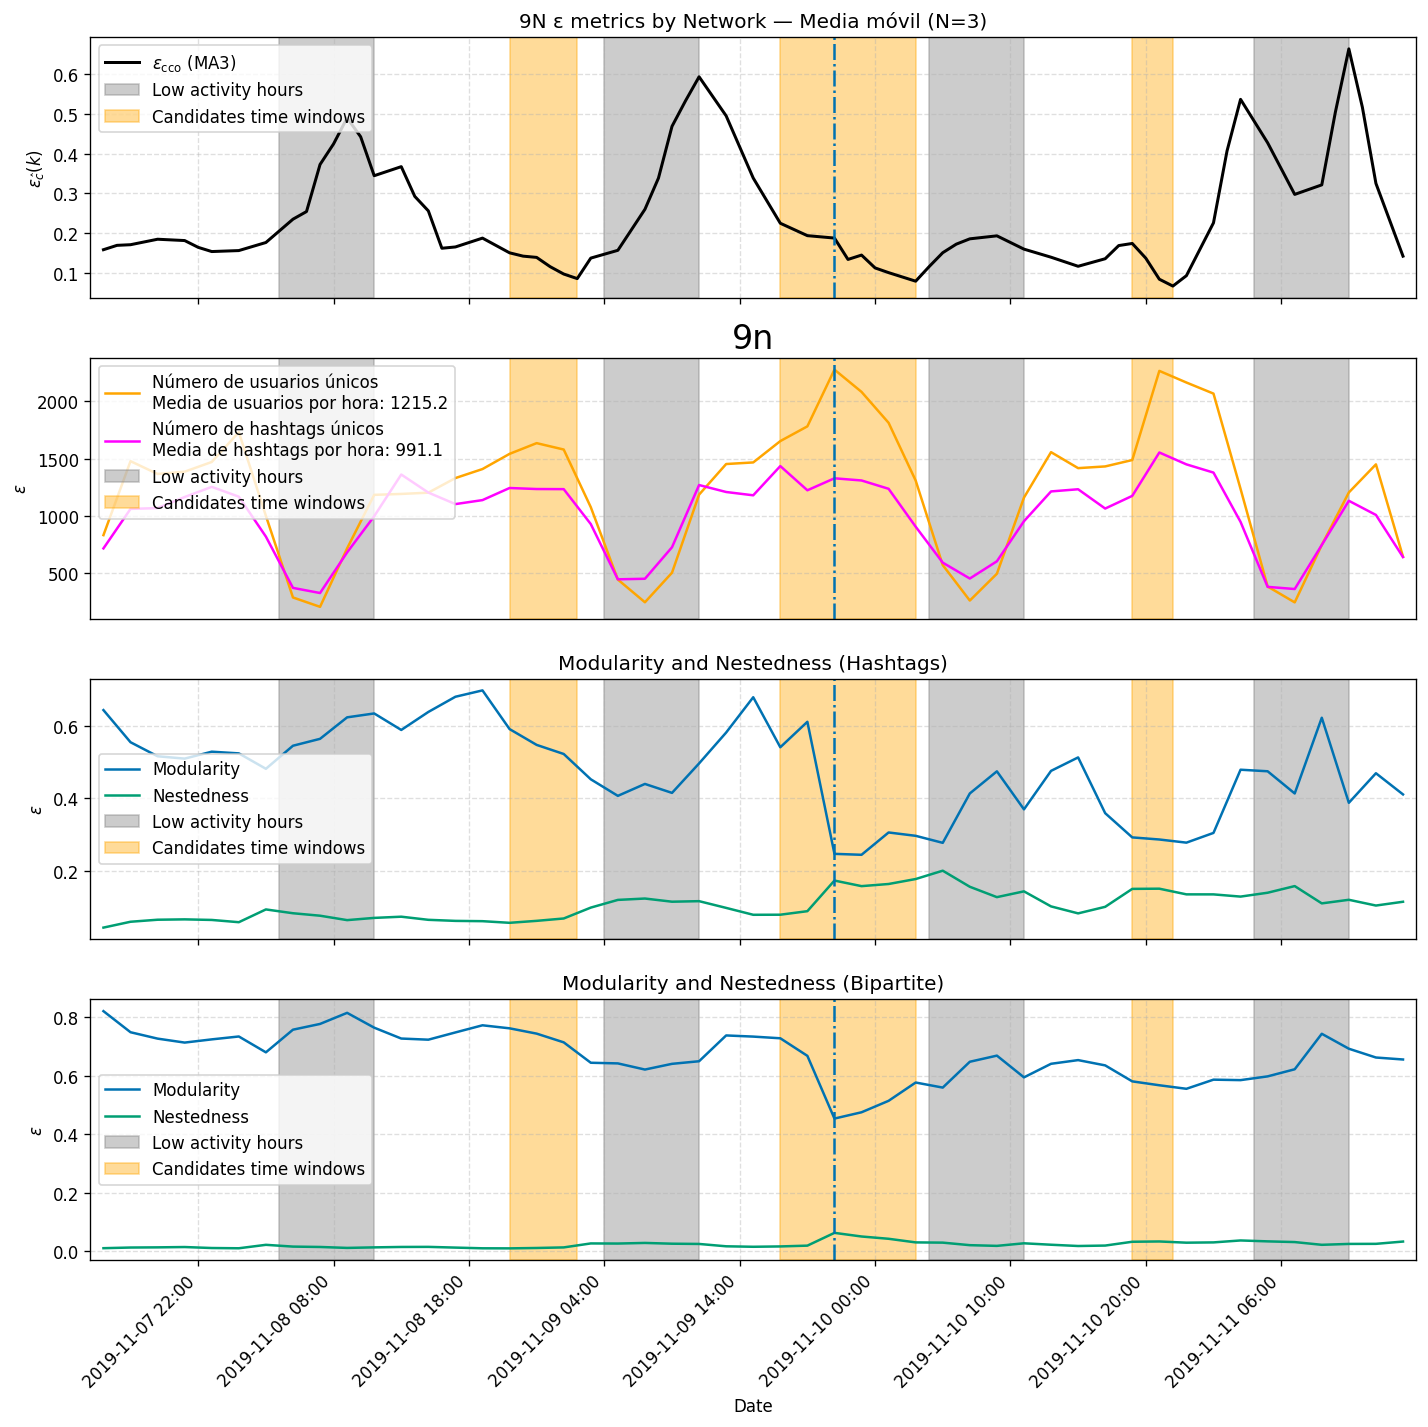

In [19]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/9n/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/9n/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
    r"$\epsilon_{\ccdf}$": "eps_ccdf",
    r"$\epsilon_{\knn}$":  "eps_knn",
    r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 12), dpi=120)
df_9n = read_data("9n", datasets_folder=datasets_folder)

hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]

num_users_9n, num_hashtags_9n = get_num_users_hashtags(df_9n, hour_window=hour_window_9n)
plot_num_users_hashtags(axes[1], hour_9n, hour_window_9n, num_users_9n, num_hashtags_9n, title="9n", inicio=0, final=140, legend=False)


hour_sort_9n_h, mod_sort_9n_h, nest_sort_9n_h = get_mod_nest_coefficient("9n", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
plot_mod_nestedness(axes[2], hour_9n, hour_window_9n, mod_sort_9n_h, nest_sort_9n_h, inicio=0, final=140, legend=False, tick_split=30, HORA_CRITICA=None)


hour_sort_9n_b, mod_sort_9n_b, nest_sort_9n_b = get_mod_nest_coefficient("9n", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
plot_mod_nestedness(axes[3], hour_9n, hour_window_9n, mod_sort_9n_b, nest_sort_9n_b, inicio=0, final=140, legend=False, tick_split=30, HORA_CRITICA=None)

def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label} (MA{N})",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for ax in axes:

	ax.axvline(int(HORA_CRITICA_9N), linestyle="-.")
	ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)      
		
	#from 00:01 to 8:00
	ax.axvspan(436996, 437003, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(437020, 437027, color='gray', alpha=0.4)
	ax.axvspan(437044, 437051, color='gray', alpha=0.4)
	ax.axvspan(437068, 437075, color='gray', alpha=0.4)
	ax.axvspan(437033, 437043, color='orange', alpha=0.4, label="Candidates time windows")
	ax.axvspan(437059, 437062, color='orange', alpha=0.4)
	ax.axvspan(437013, 437018, color='orange', alpha=0.4)
	ax.legend()
    

axes[0].set_title(f"9N ε metrics by Network — Media móvil (N={N})")
# Eje X menos cargado
axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
axes[3].set_xlabel("Date")
axes[2].set_title("Modularity and Nestedness (Hashtags)")
axes[3].set_title("Modularity and Nestedness (Bipartite)")
def horas_a_fecha(x_val, pos):
    # x_val es el número en el eje
    fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
    return fecha.strftime('%Y-%m-%d %H:%M')
axes[3].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
# Eje X menos cargado
axes[3].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[3].get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")




plt.tight_layout()
plt.show()


Calculando el anidamiento y modularidad de 9n con criterio: b


100%|██████████| 49/49 [00:00<00:00, 271853.04it/s]
/tmp/ipykernel_48670/2640764170.py:86: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


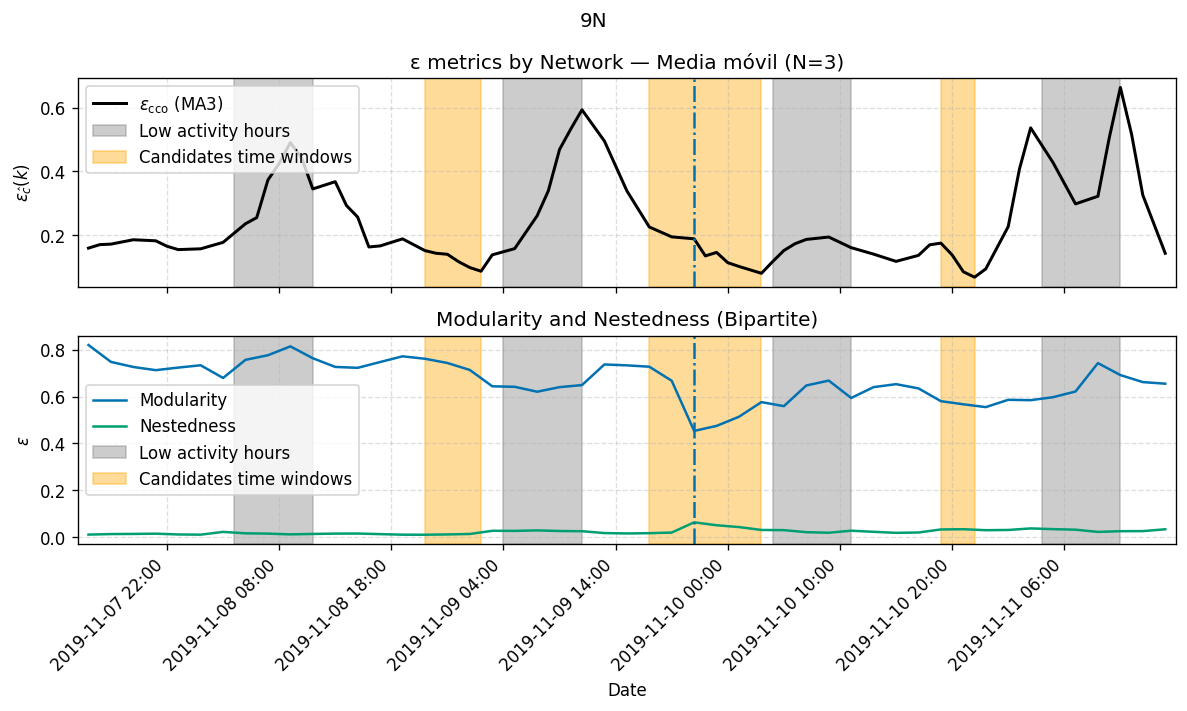

In [28]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/9n/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/9n/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
    r"$\epsilon_{\ccdf}$": "eps_ccdf",
    r"$\epsilon_{\knn}$":  "eps_knn",
    r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6), dpi=120)
df_9n = read_data("9n", datasets_folder=datasets_folder)

hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]


hour_sort_9n_b, mod_sort_9n_b, nest_sort_9n_b = get_mod_nest_coefficient("9n", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
plot_mod_nestedness(axes[1], hour_9n, hour_window_9n, mod_sort_9n_b, nest_sort_9n_b, inicio=0, final=140, legend=False, tick_split=30, HORA_CRITICA=None)

def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label} (MA{N})",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for ax in axes:

	ax.axvline(int(HORA_CRITICA_9N), linestyle="-.")
	ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)      
		
	#from 00:01 to 8:00
	ax.axvspan(436996, 437003, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(437020, 437027, color='gray', alpha=0.4)
	ax.axvspan(437044, 437051, color='gray', alpha=0.4)
	ax.axvspan(437068, 437075, color='gray', alpha=0.4)
	ax.axvspan(437033, 437043, color='orange', alpha=0.4, label="Candidates time windows")
	ax.axvspan(437059, 437062, color='orange', alpha=0.4)
	ax.axvspan(437013, 437018, color='orange', alpha=0.4)
	ax.legend()
    
fig.suptitle("9N")
axes[0].set_title(f"ε metrics by Network — Media móvil (N={N})")
# Eje X menos cargado
axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
axes[1].set_xlabel("Date")
axes[1].set_title("Modularity and Nestedness (Bipartite)")
def horas_a_fecha(x_val, pos):
    # x_val es el número en el eje
    fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
    return fecha.strftime('%Y-%m-%d %H:%M')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
# Eje X menos cargado
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[1].get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")




plt.tight_layout()
plt.show()


Calculando el anidamiento y modularidad de 9n con criterio: h


100%|██████████| 49/49 [00:00<00:00, 125317.62it/s]
/tmp/ipykernel_48670/3265341875.py:79: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


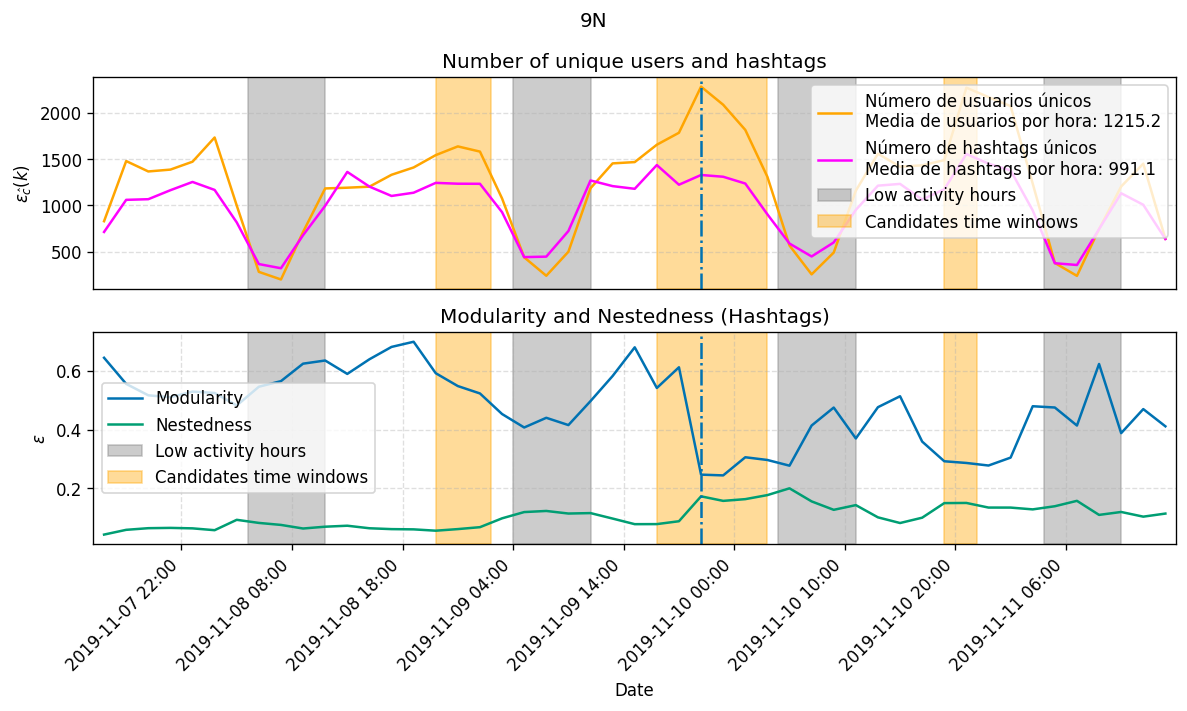

In [31]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/9n/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/9n/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
    r"$\epsilon_{\ccdf}$": "eps_ccdf",
    r"$\epsilon_{\knn}$":  "eps_knn",
    r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
    raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
    "ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
    "knn":  r"$\epsilon_{\mathrm{knn}}$",
    "cco":  r"$\epsilon_{\mathrm{cco}}$",
    "max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6), dpi=120)
df_9n = read_data("9n", datasets_folder=datasets_folder)

hour_9n = np.sort(df_9n["hour"].unique())[::hour_window_9n]

num_users_9n, num_hashtags_9n = get_num_users_hashtags(df_9n, hour_window=hour_window_9n)
plot_num_users_hashtags(axes[0], hour_9n, hour_window_9n, num_users_9n, num_hashtags_9n, title="9n", inicio=0, final=140, legend=False)


hour_sort_9n_h, mod_sort_9n_h, nest_sort_9n_h = get_mod_nest_coefficient("9n", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_9n)
plot_mod_nestedness(axes[1], hour_9n, hour_window_9n, mod_sort_9n_h, nest_sort_9n_h, inicio=0, final=140, legend=False, tick_split=30, HORA_CRITICA=None)


for ax in axes:

	ax.axvline(int(HORA_CRITICA_9N), linestyle="-.")
	ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)      
		
	#from 00:01 to 8:00
	ax.axvspan(436996, 437003, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(437020, 437027, color='gray', alpha=0.4)
	ax.axvspan(437044, 437051, color='gray', alpha=0.4)
	ax.axvspan(437068, 437075, color='gray', alpha=0.4)
	ax.axvspan(437033, 437043, color='orange', alpha=0.4, label="Candidates time windows")
	ax.axvspan(437059, 437062, color='orange', alpha=0.4)
	ax.axvspan(437013, 437018, color='orange', alpha=0.4)
	ax.legend()
    

fig.suptitle("9N")
axes[0].set_title("Number of unique users and hashtags")
# Eje X menos cargado
axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
axes[1].set_xlabel("Date")
axes[1].set_title("Modularity and Nestedness (Hashtags)")
def horas_a_fecha(x_val, pos):
    # x_val es el número en el eje
    fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
    return fecha.strftime('%Y-%m-%d %H:%M')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
# Eje X menos cargado
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[1].get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")




plt.tight_layout()
plt.show()


In [ ]:
otras_horas_ch = [str(hor) for hor in range(int(HORA_CRITICA_CH)-48, int(HORA_CRITICA_CH)+48)]
registros = []  # aquí acumulamos las filas (hora, clave_max)

for i in otras_horas_ch:
	source_path = f"graphs/nodes_hashtag/ch/{hour_window_ch}/{i}.gexf"
	out_path =  f"epsilon_sq/ch/{i}/{i}.edge"
	if not os.path.exists(f"./epsilon_sq/ch/{i}/"):
		os.makedirs(f"./epsilon_sq/ch/{i}/")
	if os.path.exists(source_path):
		gexf_a_edge(source_path, out_path)    
		# Diccionario y clave con máximo valor
		d = get_dict_hora_kt("ch", i, hour_window=hour_window_9n)
		clave_max = max(d, key=d.get) if d else None  # None si el dict está vacío

		# Guardar registro
		registros.append({"hora": i, "clave_max": clave_max})

# Construir DataFrame final (dos columnas)
df_max = pd.DataFrame(registros, columns=["hora", "clave_max"])
df_max.to_csv("./epsilon_sq/ch/kts.csv")


 16%|█▌        | 32/200 [00:00<00:00, 7033.00it/s]


Calculando el anidamiento y modularidad de ch con criterio: h


100%|██████████| 252/252 [00:00<00:00, 949653.74it/s]


Calculando el anidamiento y modularidad de ch con criterio: b


100%|██████████| 252/252 [00:00<00:00, 1051706.08it/s]
/tmp/ipykernel_48670/2584534276.py:92: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


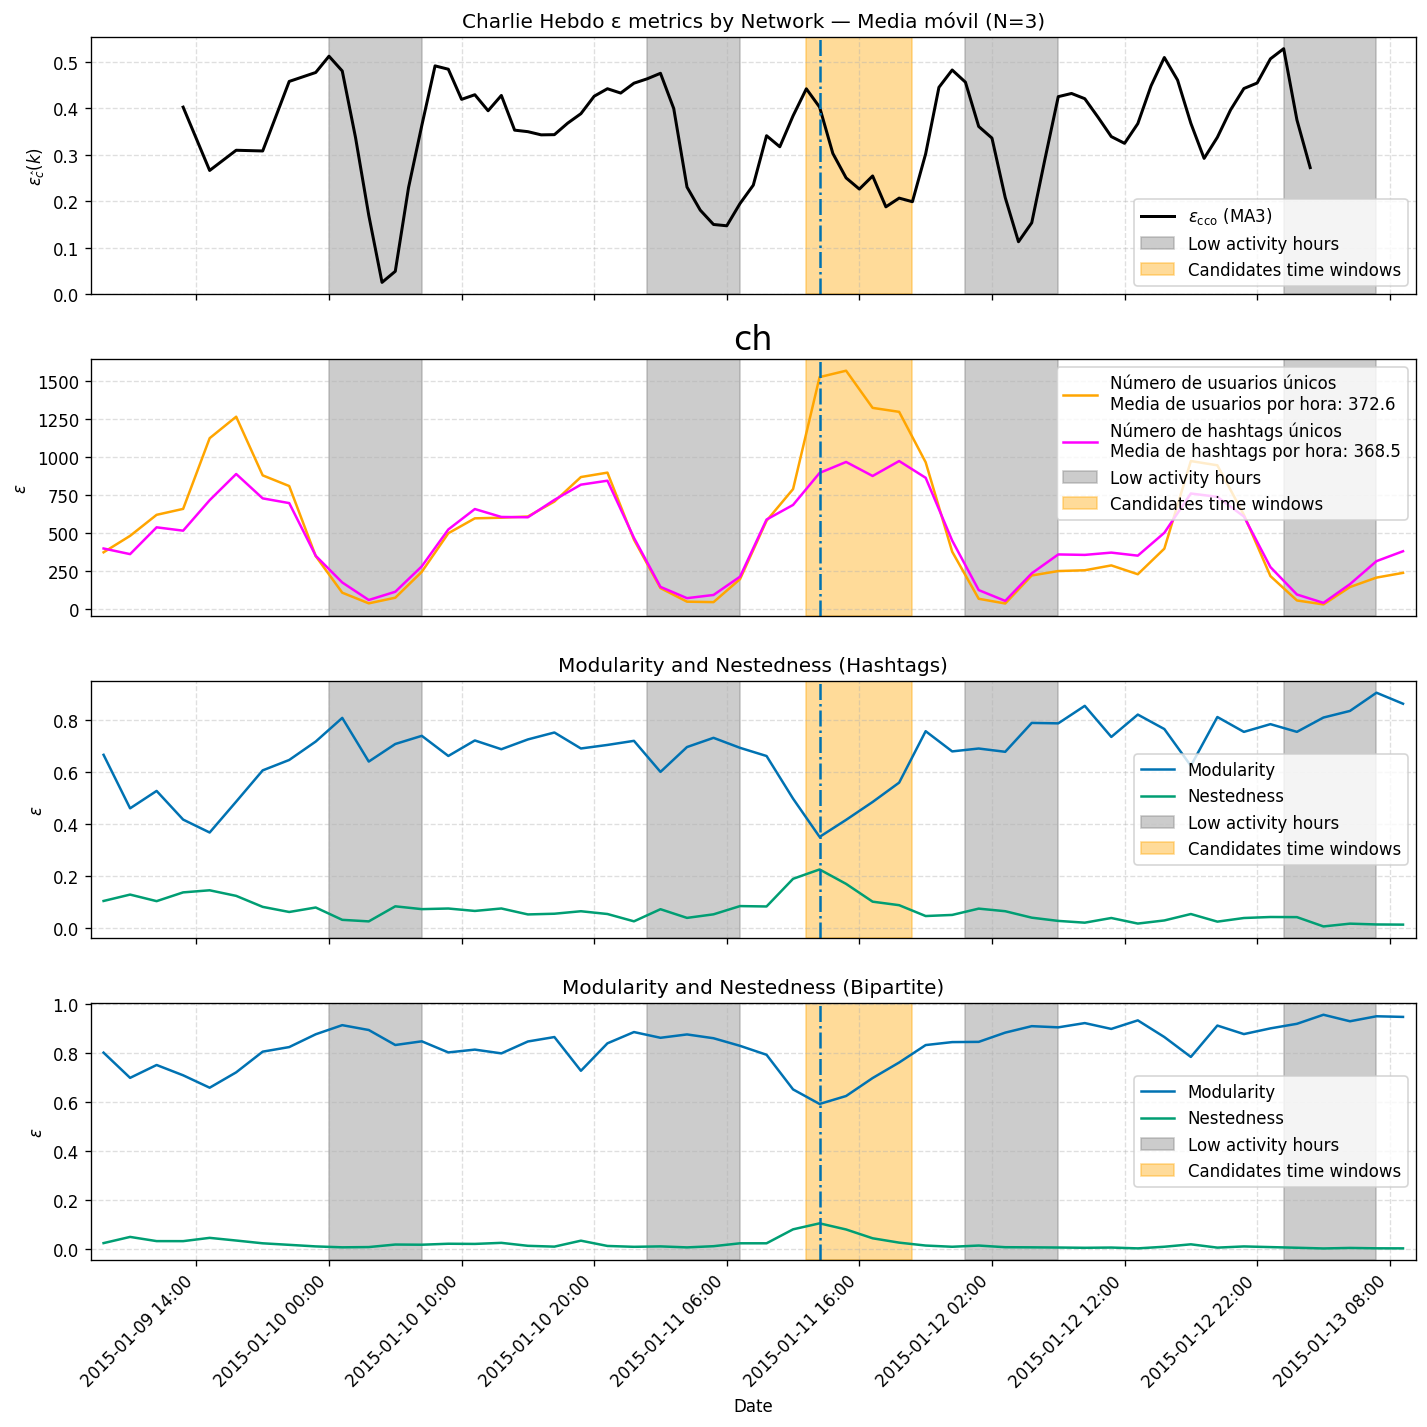

In [20]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/ch/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/ch/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
	r"$\epsilon_{\ccdf}$": "eps_ccdf",
	r"$\epsilon_{\knn}$":  "eps_knn",
	r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
	raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
	"ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
	"knn":  r"$\epsilon_{\mathrm{knn}}$",
	"cco":  r"$\epsilon_{\mathrm{cco}}$",
	"max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 12), dpi=120)


df_ch = read_data("ch", datasets_folder=datasets_folder)

hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]


num_users_ch, num_hashtags_ch = get_num_users_hashtags(df_ch, hour_window=hour_window_ch)
plot_num_users_hashtags(axes[1], hour_ch, hour_window_ch, num_users_ch, num_hashtags_ch, title="ch", inicio=200, final=300, legend=False)


hour_sort_ch_h, mod_sort_ch_h, nest_sort_ch_h = get_mod_nest_coefficient("ch", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
plot_mod_nestedness(axes[2], hour_ch, hour_window_ch, mod_sort_ch_h, nest_sort_ch_h, inicio=200, final=300, legend=False, tick_split=30, HORA_CRITICA=None)


hour_sort_ch_b, mod_sort_ch_b, nest_sort_ch_b = get_mod_nest_coefficient("ch", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
plot_mod_nestedness(axes[3], hour_ch, hour_window_ch, mod_sort_ch_b, nest_sort_ch_b, inicio=200, final=300, legend=False, tick_split=30, HORA_CRITICA=None)


def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label} (MA{N})",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for ax in axes:
	ax.axvline(int(HORA_CRITICA_CH), linestyle="-.")
	ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	ax.axvspan(394680, 394687, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(394704, 394711, color='gray', alpha=0.4)
	ax.axvspan(394728, 394735, color='gray', alpha=0.4)
	ax.axvspan(394752, 394759, color='gray', alpha=0.4)
	
	ax.axvspan(394716, 394724, color='orange', alpha=0.4, label="Candidates time windows")
	ax.legend()

axes[0].set_title(f"Charlie Hebdo ε metrics by Network — Media móvil (N={N})")
axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
axes[3].set_xlabel("Date")
axes[2].set_title("Modularity and Nestedness (Hashtags)")
axes[3].set_title("Modularity and Nestedness (Bipartite)")
def horas_a_fecha(x_val, pos):
	# x_val es el número en el eje
	fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
	return fecha.strftime('%Y-%m-%d %H:%M')
axes[3].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
# Eje X menos cargado
axes[3].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[3].get_xticklabels():
	tick.set_rotation(45)
	tick.set_ha("right")


plt.tight_layout()
plt.show()


Calculando el anidamiento y modularidad de ch con criterio: b


100%|██████████| 252/252 [00:00<00:00, 492757.39it/s]
/tmp/ipykernel_48670/790309482.py:83: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


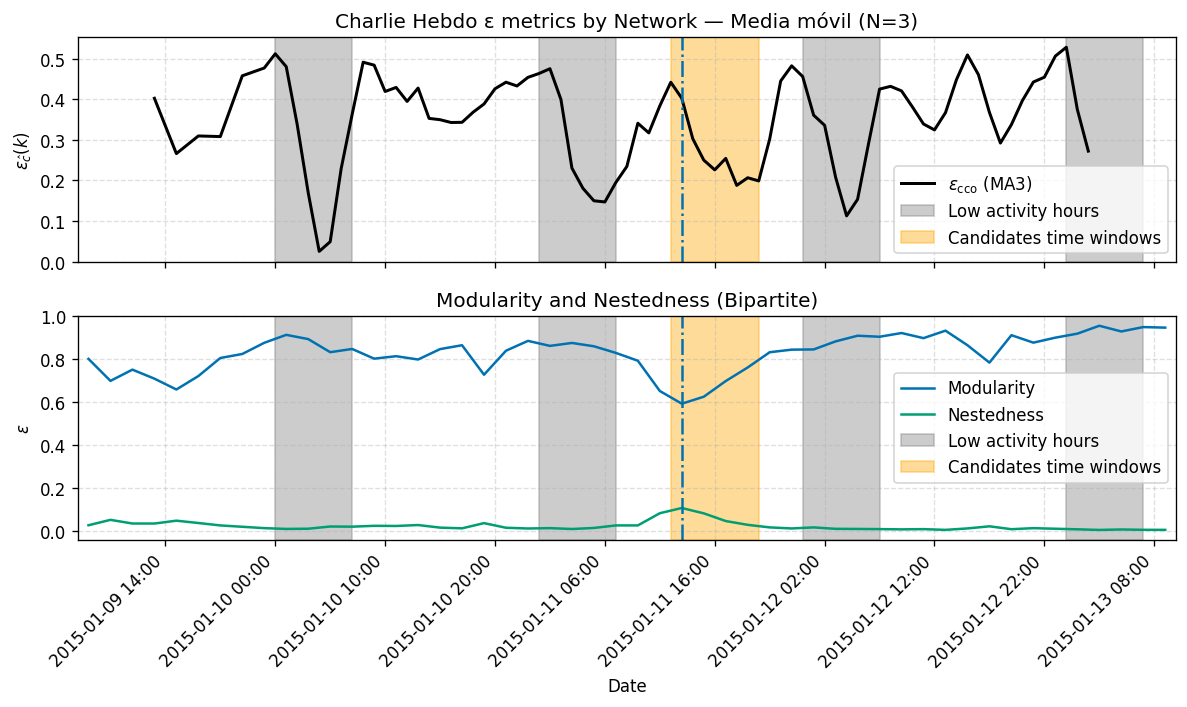

In [32]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/ch/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/ch/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
	r"$\epsilon_{\ccdf}$": "eps_ccdf",
	r"$\epsilon_{\knn}$":  "eps_knn",
	r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
	raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
	"ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
	"knn":  r"$\epsilon_{\mathrm{knn}}$",
	"cco":  r"$\epsilon_{\mathrm{cco}}$",
	"max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6), dpi=120)


df_ch = read_data("ch", datasets_folder=datasets_folder)

hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]


hour_sort_ch_b, mod_sort_ch_b, nest_sort_ch_b = get_mod_nest_coefficient("ch", "b", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
plot_mod_nestedness(axes[1], hour_ch, hour_window_ch, mod_sort_ch_b, nest_sort_ch_b, inicio=200, final=300, legend=False, tick_split=30, HORA_CRITICA=None)


def plot_ma_if_exists(ycol, label):
	if ycol is not None and ycol in df:
		y_ma = rolling_mean(df[ycol], N)
		axes[0].plot(
			x, y_ma,
			marker=None,            # no puntos: solo la media móvil
			linewidth=1.8,
			label=f"{label} (MA{N})",
            c="black"
		)
plot_ma_if_exists(cco_col, labels["cco"])

for ax in axes:
	ax.axvline(int(HORA_CRITICA_CH), linestyle="-.")
	ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	ax.axvspan(394680, 394687, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(394704, 394711, color='gray', alpha=0.4)
	ax.axvspan(394728, 394735, color='gray', alpha=0.4)
	ax.axvspan(394752, 394759, color='gray', alpha=0.4)
	
	ax.axvspan(394716, 394724, color='orange', alpha=0.4, label="Candidates time windows")
	ax.legend()

axes[0].set_title(f"Charlie Hebdo ε metrics by Network — Media móvil (N={N})")
axes[0].set_ylabel(r"$\epsilon_\hat{c}(k)$")
axes[1].set_xlabel("Date")
axes[1].set_title("Modularity and Nestedness (Bipartite)")
def horas_a_fecha(x_val, pos):
	# x_val es el número en el eje
	fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
	return fecha.strftime('%Y-%m-%d %H:%M')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
# Eje X menos cargado
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[1].get_xticklabels():
	tick.set_rotation(45)
	tick.set_ha("right")


plt.tight_layout()
plt.show()


Calculando el anidamiento y modularidad de ch con criterio: h


100%|██████████| 252/252 [00:00<00:00, 729444.17it/s]
/tmp/ipykernel_48670/1650485437.py:75: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  fecha = dt.datetime.utcfromtimestamp(x_val * 3600)


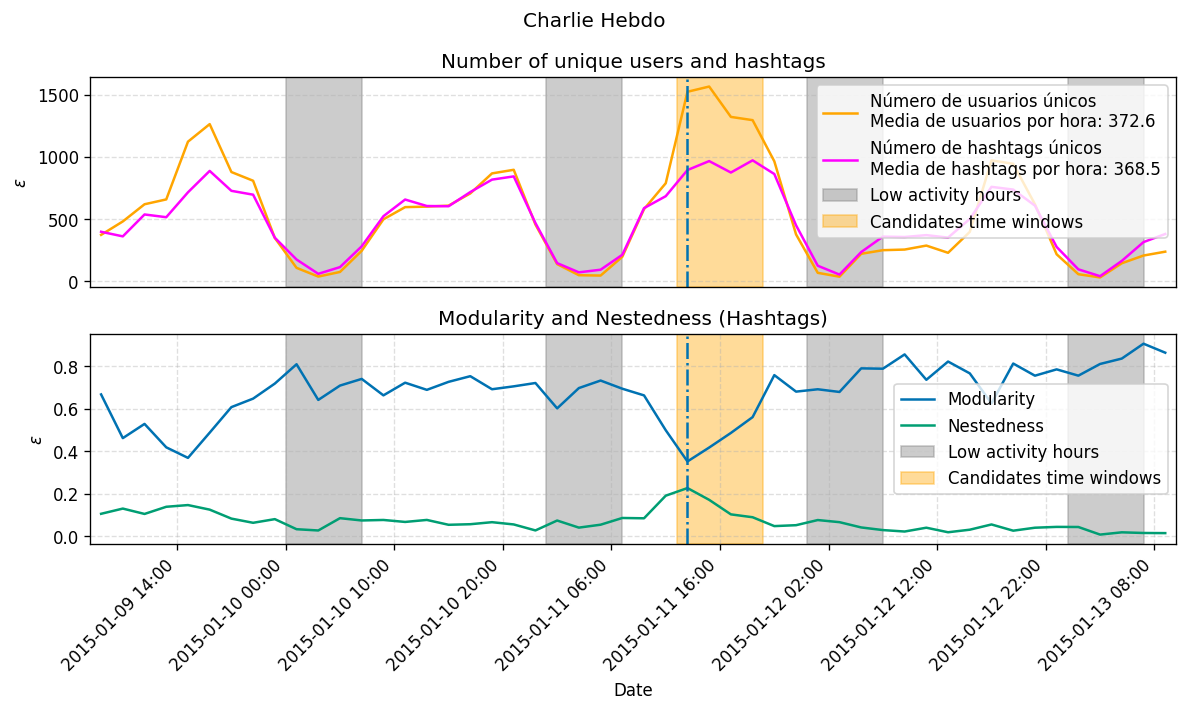

In [33]:

N = 3  # ventana de la media móvil (últimos N puntos)

df = pd.read_csv("epsilon_sq/ch/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]

df_max = pd.read_csv("epsilon_sq/ch/results/Epsilon_max_vs_clustering.txt", sep="\t")
df_max.columns = [c.strip() for c in df_max.columns]  # limpia espacios
# intenta localizar la columna de máximo de forma robusta
max_col_candidates = ["eps_max", "epsilon_max", r"$\epsilon_{max}$"]
eps_max_col = next((c for c in df_max.columns if c.strip() in max_col_candidates), None)

# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
	r"$\epsilon_{\ccdf}$": "eps_ccdf",
	r"$\epsilon_{\knn}$":  "eps_knn",
	r"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


network_col = find_col(df, ["Network", "network", "NETWORK"])
ccdf_col    = find_col(df, ["eps_ccdf", r"$\epsilon_{\ccdf}$"])
knn_col     = find_col(df, ["eps_knn",  r"$\epsilon_{\knn}$"])
cco_col     = find_col(df, ["eps_cco",  r"$\epsilon_{\cco}$"])

if network_col is None:
	raise ValueError("Couldn't find 'Network' column in the file.")

# Labels compatibles con Matplotlib mathtext
labels = {
	"ccdf": r"$\epsilon_{\mathrm{ccdf}}$",
	"knn":  r"$\epsilon_{\mathrm{knn}}$",
	"cco":  r"$\epsilon_{\mathrm{cco}}$",
	"max":  r"$\epsilon_{max}$",
}

x = df[network_col]

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6), dpi=120)


df_ch = read_data("ch", datasets_folder=datasets_folder)

hour_ch = np.sort(df_ch["hour"].unique())[::hour_window_ch]


num_users_ch, num_hashtags_ch = get_num_users_hashtags(df_ch, hour_window=hour_window_ch)
plot_num_users_hashtags(axes[0], hour_ch, hour_window_ch, num_users_ch, num_hashtags_ch, title="ch", inicio=200, final=300, legend=False)


hour_sort_ch_h, mod_sort_ch_h, nest_sort_ch_h = get_mod_nest_coefficient("ch", "h", measures_foler=measures_folder, datasets_foler=datasets_folder, graphs_folder=graphs_folder, hour_window=hour_window_ch)
plot_mod_nestedness(axes[1], hour_ch, hour_window_ch, mod_sort_ch_h, nest_sort_ch_h, inicio=200, final=300, legend=False, tick_split=30, HORA_CRITICA=None)



for ax in axes:
	ax.axvline(int(HORA_CRITICA_CH), linestyle="-.")
	ax.set_ylabel(r"$\epsilon$")
	ax.grid(True, linestyle="--", alpha=0.4)
	ax.margins(x=0.01)
	ax.axvspan(394680, 394687, color='gray', alpha=0.4, label="Low activity hours")
	ax.axvspan(394704, 394711, color='gray', alpha=0.4)
	ax.axvspan(394728, 394735, color='gray', alpha=0.4)
	ax.axvspan(394752, 394759, color='gray', alpha=0.4)
	
	ax.axvspan(394716, 394724, color='orange', alpha=0.4, label="Candidates time windows")
	ax.legend()
fig.suptitle("Charlie Hebdo")
axes[0].set_title("Number of unique users and hashtags")
axes[1].set_xlabel("Date")
axes[1].set_title("Modularity and Nestedness (Hashtags)")
def horas_a_fecha(x_val, pos):
	# x_val es el número en el eje
	fecha = dt.datetime.utcfromtimestamp(x_val * 3600)
	return fecha.strftime('%Y-%m-%d %H:%M')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(horas_a_fecha))
# Eje X menos cargado
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
for tick in axes[1].get_xticklabels():
	tick.set_rotation(45)
	tick.set_ha("right")


plt.tight_layout()
plt.show()
